# 01 - Data Audit Notebook

Notebook này là khung tự học cho **Giai đoạn 2 - Data Audit** của project Credit Risk Scoring & Loan Decisioning System.

Nguyên tắc sử dụng:
- Chỉ dùng các thông tin có trong Giai đoạn 2 của file kế hoạch.
- Hoàn thiện code theo từng checkpoint và giữ lại ghi chú kiểm tra rõ ràng.
- Không xử lý EDA/modeling sâu ở notebook này; mục tiêu là kiểm tra chất lượng dữ liệu và chuẩn bị báo cáo/pipeline validation.
- Mọi quyết định xử lý dữ liệu cần ghi lý do, không chỉ ghi kết quả.


## Section 0 - Mục tiêu và phạm vi Data Audit

**Mục tiêu:** hiểu cấu trúc, chất lượng và rủi ro dữ liệu trước khi EDA/modeling.

**Input:** dataset gốc trong `data/raw/`, đặc biệt file dataset Bài 12.

**Output mong muốn:**
- Bảng schema/data dictionary sơ bộ.
- Kết quả kiểm tra duplicate.
- Kết quả missing values và hướng xử lý đề xuất.
- Kết quả outlier/range violation theo business rules.
- Ghi chú potential leakage nếu phát hiện biến đáng nghi.
- Bản nháp nội dung cho `reports/data_quality_report.md`.
- Ý tưởng chuyển các kiểm tra quan trọng sang `src/data/validation.py`.


In [1]:
# 0.1 - Thiết lập môi trường notebook
import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# 1. Cấu hình hiển thị
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

# 2. Xác định PROJECT_ROOT
CURRENT_CWD = Path.cwd().resolve()

def find_project_root(start: Path) -> Path:
    """Tìm thư mục gốc project từ CWD hiện tại hoặc các thư mục cha."""
    for candidate in (start, *start.parents):
        if all((candidate / folder).exists() for folder in ("data", "notebooks", "src")):
            return candidate
    raise FileNotFoundError(
        "Không xác định được PROJECT_ROOT. "
        "Hãy chạy notebook từ trong repo CREDIT_RISK_PROJECT hoặc một thư mục con của repo."
    )

PROJECT_ROOT = find_project_root(CURRENT_CWD)

# 3. Khai báo đường dẫn & cấu hình biến
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DATA_PATH = RAW_DATA_DIR / "Credit Risk Dataset.xlsx"
REPORT_PATH = PROJECT_ROOT / "reports"
FIGURE_PATH = PROJECT_ROOT / "notebooks" / "figures"

DATA_SHEET_NAME = "Credit Risk Data"
DICTIONARY_SHEET_NAME = "Data Dictionary"
TARGET_COL = "loan_status"
ID_COL = "client_ID"

REPORT_PATH.mkdir(parents=True, exist_ok=True)
FIGURE_PATH.mkdir(parents=True, exist_ok=True)

# 4. Random seed
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# 5. Kiểm tra cấu hình
print(f"CWD          : {CURRENT_CWD}")
print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"RAW_DATA_PATH: {RAW_DATA_PATH}")
print(f"File tồn tại : {RAW_DATA_PATH.exists()}")
print(f"REPORT_PATH  : {REPORT_PATH}")
print(f"FIGURE_PATH  : {FIGURE_PATH}")

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"\nKhông tìm thấy dataset tại:\n{RAW_DATA_PATH}\n\n"
        "Hãy kiểm tra file 'Credit Risk Dataset.xlsx' đã nằm trong data/raw/ hay chưa."
    )

CWD          : C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT
PROJECT_ROOT : C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT
RAW_DATA_PATH: C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT\data\raw\Credit Risk Dataset.xlsx
File tồn tại : True
REPORT_PATH  : C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT\reports
FIGURE_PATH  : C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT\notebooks\figures


In [2]:
# 0.2 - Load dataset gốc

# ============================================================
# 1. Kiểm tra file trước khi load
# ============================================================

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy dữ liệu raw tại: {RAW_DATA_PATH}")

file_suffix = RAW_DATA_PATH.suffix.lower()

# ============================================================
# 2. Load dữ liệu
# ============================================================

if file_suffix in {".xlsx", ".xls"}:
    excel_file = pd.ExcelFile(RAW_DATA_PATH, engine="openpyxl")
    print(f"Các sheet trong workbook: {excel_file.sheet_names}")

    if DATA_SHEET_NAME not in excel_file.sheet_names:
        raise ValueError(
            f"Không tìm thấy sheet '{DATA_SHEET_NAME}'. "
            f"Các sheet hiện có: {excel_file.sheet_names}"
        )

    df_raw = pd.read_excel(
        RAW_DATA_PATH,
        sheet_name=DATA_SHEET_NAME,
        engine="openpyxl",
    )

elif file_suffix == ".csv":
    df_raw = pd.read_csv(RAW_DATA_PATH)

else:
    raise ValueError(f"Định dạng file chưa được hỗ trợ: {file_suffix}")

RAW_SHAPE = df_raw.shape

# ============================================================
# 3. Tổng quan dataset
# ============================================================

print("\n" + "=" * 70)
print(f"Dataset raw: {RAW_SHAPE[0]:,} dòng × {RAW_SHAPE[1]} cột")
print("=" * 70)

print("\n--- 5 dòng đầu tiên ---")
display(df_raw.head())

print("\n--- Thông tin DataFrame ---")
df_raw.info(memory_usage="deep")

# ============================================================
# 4. Kiểm tra nhanh sau khi load
# ============================================================

print("\n--- Kiểm tra nhanh sau khi load (chưa xử lý dữ liệu) ---")
print(f"Target '{TARGET_COL}' tồn tại : {TARGET_COL in df_raw.columns}")
print(f"ID '{ID_COL}' tồn tại         : {ID_COL in df_raw.columns}")
print(f"Tên cột bị trùng             : {int(df_raw.columns.duplicated().sum())}")

unnamed_count = sum(str(col).startswith("Unnamed") for col in df_raw.columns)
print(f"Cột kiểu 'Unnamed'           : {unnamed_count}")

# ============================================================
# 5. Kiểm tra missing values sơ bộ
# ============================================================

missing_summary = (
    df_raw
    .isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

missing_summary["missing_rate"] = missing_summary["missing_count"] / len(df_raw)

missing_summary = (
    missing_summary
    .query("missing_count > 0")
    .sort_values("missing_rate", ascending=False)
)

if missing_summary.empty:
    print("Missing values               : Không có")
else:
    print(f"Missing values               : {len(missing_summary)} cột có giá trị thiếu")
    display(missing_summary)

Các sheet trong workbook: ['Credit Risk Data', 'Data Dictionary']



Dataset raw: 32,581 dòng × 29 cột

--- 5 dòng đầu tiên ---


,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,gender,marital_status,education_level,country,state,city,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0000,PERSONAL,D,35000,16.0200,1,0.5900,Y,3,Male,Married,High School,Canada,Ontario,Toronto,43.6532,-79.3832,Self-employed,36,0.5932,"8,402.4538",0.7356,14,0.4956,0
1,CUST_00002,21,9600,OWN,5.0000,EDUCATION,B,1000,11.1400,0,0.1000,N,2,Female,Divorced,Master,Canada,Ontario,Toronto,43.6532,-79.3832,Full-time,36,0.1042,"1,607.8028",0.2716,10,0.5854,3
2,CUST_00003,25,9600,MORTGAGE,1.0000,MEDICAL,C,5500,12.8700,1,0.5700,N,3,Female,Married,Master,UK,Wales,Swansea,51.6214,-3.9436,Full-time,36,0.5729,"2,760.5056",0.8605,14,0.7507,0
3,CUST_00004,23,65500,RENT,4.0000,MEDICAL,C,35000,15.2300,1,0.5300,N,2,Male,Married,Bachelor,Canada,BC,Vancouver,49.2827,-123.1207,Part-time,12,0.5344,"7,155.2862",0.6436,15,0.3793,0
4,CUST_00005,24,54400,RENT,8.0000,MEDICAL,C,35000,14.2700,1,0.5500,Y,4,Female,Single,Bachelor,USA,New York,Buffalo,42.8864,-78.8784,Part-time,36,0.6434,"15,626.1534",0.9306,4,0.2281,0



--- Thông tin DataFrame ---


<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  str    
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  str    
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  str    
 6   loan_grade                  32581 non-null  str    
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  str    
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender                      32581 non-null


--- Kiểm tra nhanh sau khi load (chưa xử lý dữ liệu) ---
Target 'loan_status' tồn tại : True
ID 'client_ID' tồn tại         : True
Tên cột bị trùng             : 0
Cột kiểu 'Unnamed'           : 0
Missing values               : 2 cột có giá trị thiếu


,missing_count,missing_rate
loan_int_rate,3116,0.0956
person_emp_length,895,0.0275


## Section 1 - 2.1 Kiểm tra Schema và Data Dictionary

Theo kế hoạch, với từng cột cần kiểm tra: kiểu dữ liệu, min/max, missing, unique, distribution và business meaning. Kết quả cần gom thành một **Data Dictionary** chuẩn.

In [3]:
# 1.1 - Tổng quan schema kỹ thuật

# ============================================================
# 1. Khai báo các cột đặc biệt & 2. Hàm hỗ trợ phân loại biến
# ============================================================

TARGET_COL = globals().get("TARGET_COL", "loan_status")
ID_COL = globals().get("ID_COL", "client_ID")

def infer_variable_type(series: pd.Series, column_name: str) -> str:
    """Phân loại kỹ thuật sơ bộ cho một cột."""
    if column_name == TARGET_COL:
        return "target"
    if column_name == ID_COL:
        return "identifier"
    
    unique_count = series.nunique(dropna=True)

    if pd.api.types.is_bool_dtype(series) or unique_count == 2:
        return "boolean-like"
    if pd.api.types.is_object_dtype(series) or isinstance(series.dtype, pd.CategoricalDtype):
        return "categorical"
    if pd.api.types.is_numeric_dtype(series):
        return "numeric"
    return "other"

def get_sample_values(series: pd.Series, n: int = 5) -> list:
    """Lấy tối đa n giá trị khác nhau để xem nhanh miền dữ liệu."""
    return series.dropna().unique()[:n].tolist()

def get_dtype_review_note(series: pd.Series, column_name: str) -> str:
    """Gắn cảnh báo sơ bộ cho những cột cần kiểm tra dtype/cardinality kỹ hơn."""
    unique_count = series.nunique(dropna=True)

    if column_name == ID_COL:
        return "Identifier - không dùng trực tiếp làm feature modeling"
    if column_name == TARGET_COL:
        return "Target nhị phân - cần xác nhận ý nghĩa nhãn 0/1"
    
    if pd.api.types.is_float_dtype(series):
        non_null = series.dropna()
        if len(non_null) > 0 and np.all(np.isclose(non_null, np.round(non_null))):
            return "Float nhưng giá trị quan sát được là số nguyên; có thể do missing values"
            
    if pd.api.types.is_numeric_dtype(series) and unique_count <= 10:
        return "Numeric cardinality thấp - kiểm tra đây là biến số rời rạc hay categorical"
        
    if pd.api.types.is_object_dtype(series) and unique_count > 50:
        return "Categorical cardinality cao - kiểm tra có phải identifier/text field hay không"
        
    return ""

# ============================================================
# 3. Tạo schema summary
# ============================================================

schema_records = []
n_rows = len(df_raw)

for column in df_raw.columns:
    series = df_raw[column]
    non_null_count = int(series.notna().sum())
    missing_count = int(series.isna().sum())
    unique_count = int(series.nunique(dropna=True))

    schema_records.append({
        "column": column,
        "dtype": str(series.dtype),
        "variable_type": infer_variable_type(series, column),
        "non_null_count": non_null_count,
        "missing_count": missing_count,
        "missing_rate": missing_count / n_rows,
        "unique_count": unique_count,
        "sample_values": get_sample_values(series),
        "is_target": column == TARGET_COL,
        "is_identifier": column == ID_COL,
        "dtype_review_note": get_dtype_review_note(series, column),
    })

schema_summary = pd.DataFrame(schema_records)

# ============================================================
# 4. Sắp xếp để audit dễ hơn
# ============================================================

schema_summary = (
    schema_summary
    .sort_values(by=["missing_rate", "unique_count"], ascending=[False, False])
    .reset_index(drop=True)
)

# ============================================================
# 5. Hiển thị schema
# ============================================================

print("=" * 80)
print("SCHEMA SUMMARY")
print("=" * 80)
print(f"Số dòng dataset : {df_raw.shape[0]:,}")
print(f"Số cột dataset  : {df_raw.shape[1]}")
print(f"Target          : {TARGET_COL}")
print(f"Identifier      : {ID_COL}")

display(schema_summary.style.format({"missing_rate": "{:.2%}"}))

# ============================================================
# 6. Tổng hợp loại biến & 7. Các cột cần kiểm tra kỹ hơn
# ============================================================

print("\n--- Phân loại biến sơ bộ ---")
variable_type_summary = (
    schema_summary["variable_type"]
    .value_counts()
    .rename_axis("variable_type")
    .reset_index(name="column_count")
)
display(variable_type_summary)

columns_need_review = (
    schema_summary.loc[
        schema_summary["dtype_review_note"].ne(""),
        ["column", "dtype", "variable_type", "unique_count", "missing_count", "missing_rate", "dtype_review_note"]
    ]
    .copy()
    .reset_index(drop=True)
)

print("\n--- Các cột cần kiểm tra kỹ hơn ---")
if columns_need_review.empty:
    print("Không phát hiện cột nào cần review dtype sơ bộ.")
else:
    display(columns_need_review.style.format({"missing_rate": "{:.2%}"}))

SCHEMA SUMMARY
Số dòng dataset : 32,581
Số cột dataset  : 29
Target          : loan_status
Identifier      : client_ID


,column,dtype,variable_type,non_null_count,missing_count,missing_rate,unique_count,sample_values,is_target,is_identifier,dtype_review_note
0,loan_int_rate,float64,numeric,29465,3116,9.56%,348,"[16.02, 11.14, 12.87, 15.23, 14.27]",False,False,
1,person_emp_length,float64,numeric,31686,895,2.75%,36,"[123.0, 5.0, 1.0, 4.0, 8.0]",False,False,Float nhưng giá trị quan sát được là số nguyên; có thể do missing values
2,client_ID,str,identifier,32581,0,0.00%,32581,"['CUST_00001', 'CUST_00002', 'CUST_00003', 'CUST_00004', 'CUST_00005']",False,True,Identifier - không dùng trực tiếp làm feature modeling
3,other_debt,float64,numeric,32581,0,0.00%,32581,"[8402.453849533113, 1607.802794435836, 2760.505633222081, 7155.286150089593, 15626.15343940794]",False,False,
4,debt_to_income_ratio,float64,numeric,32581,0,0.00%,32581,"[0.7356348110090358, 0.2716461244203996, 0.8604693367939668, 0.6435921549632, 0.9306278205773516]",False,False,
5,credit_utilization_ratio,float64,numeric,32581,0,0.00%,32581,"[0.495556687418608, 0.5854360215997556, 0.7507318369907078, 0.3793334268112993, 0.2281027070279239]",False,False,
6,loan_to_income_ratio,float64,numeric,32581,0,0.00%,9914,"[0.5932203389830508, 0.1041666666666666, 0.5729166666666666, 0.5343511450381679, 0.6433823529411765]",False,False,
7,person_income,int64,numeric,32581,0,0.00%,4295,"[59000, 9600, 65500, 54400, 9900]",False,False,
8,loan_amnt,int64,numeric,32581,0,0.00%,753,"[35000, 1000, 5500, 2500, 1600]",False,False,
9,loan_percent_income,float64,numeric,32581,0,0.00%,77,"[0.59, 0.1, 0.57, 0.53, 0.55]",False,False,



--- Phân loại biến sơ bộ ---


,variable_type,column_count
0,numeric,16
1,other,9
2,boolean-like,2
3,identifier,1
4,target,1



--- Các cột cần kiểm tra kỹ hơn ---


,column,dtype,variable_type,unique_count,missing_count,missing_rate,dtype_review_note
0,person_emp_length,float64,numeric,36,895,2.75%,Float nhưng giá trị quan sát được là số nguyên; có thể do missing values
1,client_ID,str,identifier,32581,0,0.00%,Identifier - không dùng trực tiếp làm feature modeling
2,past_delinquencies,int64,numeric,7,0,0.00%,Numeric cardinality thấp - kiểm tra đây là biến số rời rạc hay categorical
3,loan_term_months,int64,numeric,4,0,0.00%,Numeric cardinality thấp - kiểm tra đây là biến số rời rạc hay categorical
4,loan_status,int64,target,2,0,0.00%,Target nhị phân - cần xác nhận ý nghĩa nhãn 0/1


In [4]:
# 1.2 - Min/Max và thống kê numeric

# ============================================================
# 1. Xác định các biến numeric
# ============================================================

numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()

print(f"Số biến numeric: {len(numeric_cols)}")
print(numeric_cols)

# ============================================================
# 2. Thống kê mô tả
# ============================================================

PERCENTILES = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]

base_stats = (
    df_raw[numeric_cols]
    .describe(percentiles=PERCENTILES)
    .T
    .rename(columns={"50%": "median"})
)

numeric_summary = pd.DataFrame(index=numeric_cols)
numeric_summary["dtype"] = df_raw[numeric_cols].dtypes.astype(str)
numeric_summary["non_null_count"] = df_raw[numeric_cols].notna().sum()
numeric_summary["missing_count"] = df_raw[numeric_cols].isna().sum()
numeric_summary["missing_rate"] = df_raw[numeric_cols].isna().mean()

stat_columns = ["min", "1%", "5%", "25%", "median", "75%", "95%", "99%", "max", "mean", "std"]
for col in stat_columns:
    numeric_summary[col] = base_stats[col]

# ============================================================
# 3. Thống kê bổ sung phục vụ Data Quality Audit
# ============================================================

numeric_summary["skewness"] = df_raw[numeric_cols].skew(numeric_only=True)
numeric_summary["zero_count"] = (df_raw[numeric_cols] == 0).sum()
numeric_summary["negative_count"] = (df_raw[numeric_cols] < 0).sum()
numeric_summary["is_target"] = [col == TARGET_COL for col in numeric_cols]

# ============================================================
# 4. Audit range sơ bộ
# ============================================================

range_review_notes = {col: [] for col in numeric_cols}

def add_numeric_note(column: str, note: str) -> None:
    """Thêm ghi chú audit cho biến numeric."""
    if column in range_review_notes:
        range_review_notes[column].append(note)

# Age
if "person_age" in df_raw.columns:
    invalid_age = df_raw["person_age"].notna() & ((df_raw["person_age"] < 20) | (df_raw["person_age"] > 100))
    if invalid_age.any():
        add_numeric_note("person_age", f"Có {invalid_age.sum():,} giá trị ngoài ngưỡng audit sơ bộ 20–100; cần kiểm tra business rule.")

# Employment length
MIN_WORKING_AGE_FOR_AUDIT = 14
if {"person_emp_length", "person_age"}.issubset(df_raw.columns):
    emp_invalid = df_raw["person_emp_length"].notna() & ((df_raw["person_emp_length"] < 0) | (df_raw["person_emp_length"] > (df_raw["person_age"] - MIN_WORKING_AGE_FOR_AUDIT)))
    if emp_invalid.any():
        add_numeric_note("person_emp_length", f"Có {emp_invalid.sum():,} dòng có employment length < 0 hoặc > age - {MIN_WORKING_AGE_FOR_AUDIT}; cần kiểm tra row-level.")

# Các đại lượng tài chính phải dương
for col in ["person_income", "loan_amnt", "loan_int_rate"]:
    if col not in df_raw.columns:
        continue
    invalid = df_raw[col].notna() & (df_raw[col] <= 0)
    if invalid.any():
        add_numeric_note(col, f"Có {invalid.sum():,} giá trị <= 0; cần xác minh nghiệp vụ.")

# Ratio không nên âm
ratio_cols = ["loan_percent_income", "loan_to_income_ratio", "debt_to_income_ratio", "credit_utilization_ratio"]
for col in ratio_cols:
    if col not in df_raw.columns:
        continue
    negative_mask = df_raw[col].notna() & (df_raw[col] < 0)
    if negative_mask.any():
        add_numeric_note(col, f"Có {negative_mask.sum():,} giá trị âm; cần xác minh.")

if "credit_utilization_ratio" in df_raw.columns:
    utilization_invalid = df_raw["credit_utilization_ratio"].notna() & ((df_raw["credit_utilization_ratio"] < 0) | (df_raw["credit_utilization_ratio"] > 1))
    if utilization_invalid.any():
        add_numeric_note("credit_utilization_ratio", f"Có {utilization_invalid.sum():,} giá trị nằm ngoài khoảng [0, 1].")

# Phân phối lệch mạnh
STRONG_SKEW_THRESHOLD = 2.0
for col in numeric_cols:
    if col == TARGET_COL:
        continue
    skew_value = numeric_summary.loc[col, "skewness"]
    if pd.notna(skew_value) and abs(skew_value) >= STRONG_SKEW_THRESHOLD:
        add_numeric_note(col, f"Phân phối lệch mạnh (skew={skew_value:.2f}); cần kiểm tra quantile/outlier sâu hơn.")

# ============================================================
# 5. Ghép audit notes & 6. Danh sách biến cần outlier review
# ============================================================

numeric_summary["audit_note"] = [" | ".join(range_review_notes[col]) for col in numeric_cols]
numeric_summary.index.name = "column"
numeric_summary = numeric_summary.reset_index()

numeric_columns_for_outlier_review = (
    numeric_summary.loc[numeric_summary["audit_note"].ne(""), "column"]
    .tolist()
)

# ============================================================
# 7. Hiển thị kết quả
# ============================================================

print("\n" + "=" * 85)
print("NUMERIC SUMMARY")
print("=" * 85)

display(
    numeric_summary.style.format({
        "missing_rate": "{:.2%}",
        "min": "{:,.4f}", "1%": "{:,.4f}", "5%": "{:,.4f}", "25%": "{:,.4f}",
        "median": "{:,.4f}", "75%": "{:,.4f}", "95%": "{:,.4f}", "99%": "{:,.4f}",
        "max": "{:,.4f}", "mean": "{:,.4f}", "std": "{:,.4f}", "skewness": "{:.2f}"
    })
)

print("\n--- Các biến cần outlier/range review sâu hơn ---")

if not numeric_columns_for_outlier_review:
    print("Chưa phát hiện biến numeric cần review đặc biệt.")
else:
    print(numeric_columns_for_outlier_review)
    display(
        numeric_summary.loc[
            numeric_summary["column"].isin(numeric_columns_for_outlier_review),
            ["column", "min", "1%", "median", "99%", "max", "skewness", "missing_rate", "audit_note"]
        ].style.format({
            "missing_rate": "{:.2%}",
            "min": "{:,.4f}", "1%": "{:,.4f}", "median": "{:,.4f}",
            "99%": "{:,.4f}", "max": "{:,.4f}", "skewness": "{:.2f}"
        })
    )

Số biến numeric: 17
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length', 'city_latitude', 'city_longitude', 'loan_term_months', 'loan_to_income_ratio', 'other_debt', 'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio', 'past_delinquencies']

NUMERIC SUMMARY


,column,dtype,non_null_count,missing_count,missing_rate,min,1%,5%,25%,median,75%,95%,99%,max,mean,std,skewness,zero_count,negative_count,is_target,audit_note
0,person_age,int64,32581,0,0.00%,20.0000,21.0000,22.0000,23.0000,26.0000,30.0000,40.0000,50.0000,144.0000,27.7346,6.3481,2.58,0,0,False,Có 5 giá trị ngoài ngưỡng audit sơ bộ 20–100; cần kiểm tra business rule. | Phân phối lệch mạnh (skew=2.58); cần kiểm tra quantile/outlier sâu hơn.
1,person_income,int64,32581,0,0.00%,"4,000.0000","14,400.0000","22,880.0000","38,500.0000","55,000.0000","79,200.0000","138,000.0000","225,200.0000","6,000,000.0000","66,074.8485","61,983.1192",32.87,0,0,False,Phân phối lệch mạnh (skew=32.87); cần kiểm tra quantile/outlier sâu hơn.
2,person_emp_length,float64,31686,895,2.75%,0.0000,0.0000,0.0000,2.0000,4.0000,7.0000,13.0000,18.0000,123.0000,4.7897,4.1426,2.61,4105,0,False,Có 2 dòng có employment length < 0 hoặc > age - 14; cần kiểm tra row-level. | Phân phối lệch mạnh (skew=2.61); cần kiểm tra quantile/outlier sâu hơn.
3,loan_amnt,int64,32581,0,0.00%,500.0000,"1,000.0000","2,000.0000","5,000.0000","8,000.0000","12,200.0000","24,000.0000","29,800.0000","35,000.0000","9,589.3711","6,322.0866",1.19,0,0,False,
4,loan_int_rate,float64,29465,3116,9.56%,5.4200,5.4200,6.0300,7.9000,10.9900,13.4700,16.3200,18.6200,23.2200,11.0117,3.2405,0.21,0,0,False,
5,loan_status,int64,32581,0,0.00%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.2182,0.4130,1.36,25473,0,True,
6,loan_percent_income,float64,32581,0,0.00%,0.0000,0.0200,0.0400,0.0900,0.1500,0.2300,0.3800,0.5000,0.8300,0.1702,0.1068,1.06,9,0,False,
7,cb_person_cred_hist_length,int64,32581,0,0.00%,2.0000,2.0000,2.0000,3.0000,4.0000,8.0000,14.0000,17.0000,30.0000,5.8042,4.0550,1.66,0,0,False,
8,city_latitude,float64,32581,0,0.00%,29.7604,29.7604,29.7604,40.7128,46.8139,51.5074,55.9533,55.9533,55.9533,45.4076,7.6448,-0.53,0,0,False,
9,city_longitude,float64,32581,0,0.00%,-123.3656,-123.3656,-123.3656,-96.7970,-75.6972,-3.9436,-0.1278,-0.1278,-0.1278,-63.8055,46.6156,0.27,0,32581,False,



--- Các biến cần outlier/range review sâu hơn ---
['person_age', 'person_income', 'person_emp_length', 'other_debt']


,column,min,1%,median,99%,max,skewness,missing_rate,audit_note
0,person_age,20.0000,21.0000,26.0000,50.0000,144.0000,2.58,0.00%,Có 5 giá trị ngoài ngưỡng audit sơ bộ 20–100; cần kiểm tra business rule. | Phân phối lệch mạnh (skew=2.58); cần kiểm tra quantile/outlier sâu hơn.
1,person_income,"4,000.0000","14,400.0000","55,000.0000","225,200.0000","6,000,000.0000",32.87,0.00%,Phân phối lệch mạnh (skew=32.87); cần kiểm tra quantile/outlier sâu hơn.
2,person_emp_length,0.0000,0.0000,4.0000,18.0000,123.0000,2.61,2.75%,Có 2 dòng có employment length < 0 hoặc > age - 14; cần kiểm tra row-level. | Phân phối lệch mạnh (skew=2.61); cần kiểm tra quantile/outlier sâu hơn.
12,other_debt,225.2074,"1,483.1146","8,995.0706","46,354.6458","1,187,998.9145",28.46,0.00%,Phân phối lệch mạnh (skew=28.46); cần kiểm tra quantile/outlier sâu hơn.


In [5]:
# 1.3 - Unique values và phân phối categorical

# ============================================================
# 1. Xác định categorical/binary columns
# ============================================================

object_cols = df_raw.select_dtypes(include=["str", "category", "bool"]).columns.tolist()

binary_numeric_cols = [
    col for col in df_raw.select_dtypes(include=[np.number]).columns
    if df_raw[col].nunique(dropna=True) == 2
]

categorical_cols = list(dict.fromkeys(object_cols + binary_numeric_cols))

print(f"Số biến categorical/binary được audit: {len(categorical_cols)}")
print(categorical_cols)

# ============================================================
# 2. Các tham số audit
# ============================================================

RARE_CATEGORY_THRESHOLD = 0.01
HIGH_CARDINALITY_THRESHOLD = 50

STRING_MISSING_TOKENS = {"", "NA", "N/A", "NULL", "NONE", "UNKNOWN", "?", "NAN"}

# ============================================================
# 3. Tạo categorical summary
# ============================================================

categorical_records = []

for col in categorical_cols:
    series = df_raw[col]
    unique_count = int(series.nunique(dropna=True))
    missing_count = int(series.isna().sum())
    missing_rate = missing_count / len(df_raw)
    
    value_counts = series.value_counts(dropna=False)

    if len(value_counts) > 0:
        top_value = value_counts.index[0]
        top_count = int(value_counts.iloc[0])
        top_rate = top_count / len(df_raw)
    else:
        top_value = None
        top_count = 0
        top_rate = np.nan

    # Top 5 values
    top_values_parts = []
    for value, count in value_counts.head(5).items():
        value_label = "<MISSING>" if pd.isna(value) else str(value)
        rate = count / len(df_raw)
        top_values_parts.append(f"{value_label}: {count:,} ({rate:.2%})")
    top_values = " | ".join(top_values_parts)

    # Rare categories
    if col == ID_COL:
        rare_count = np.nan
        rare_categories = []
    else:
        non_missing_counts = series.value_counts(dropna=True)
        non_missing_total = non_missing_counts.sum()

        if non_missing_total > 0:
            category_rates = non_missing_counts / non_missing_total
            rare = category_rates[category_rates < RARE_CATEGORY_THRESHOLD]
            rare_count = int(len(rare))
            rare_categories = rare.index.astype(str).tolist()
        else:
            rare_count = 0
            rare_categories = []

    categorical_records.append({
        "column": col,
        "dtype": str(series.dtype),
        "unique_count": unique_count,
        "missing_count": missing_count,
        "missing_rate": missing_rate,
        "top_value": top_value,
        "top_count": top_count,
        "top_rate": top_rate,
        "top_values": top_values,
        "rare_category_count_lt_1pct": rare_count,
        "rare_categories_lt_1pct": rare_categories,
        "is_identifier": col == ID_COL,
        "is_target": col == TARGET_COL,
    })

categorical_summary = pd.DataFrame(categorical_records)

# ============================================================
# 4. Kiểm tra missing giả dạng chuỗi & 5. Whitespace/case inconsistency
# ============================================================

string_missing_records = []
normalization_issue_records = []

for col in object_cols:
    non_null_series = df_raw[col].dropna().astype(str)
    
    # Missing giả dạng chuỗi
    normalized = non_null_series.str.strip().str.upper()
    suspicious_tokens = normalized[normalized.isin(STRING_MISSING_TOKENS)].value_counts()
    if not suspicious_tokens.empty:
        string_missing_records.append({
            "column": col,
            "token_counts": suspicious_tokens.to_dict(),
            "total": int(suspicious_tokens.sum()),
        })

    # Whitespace/case inconsistency (Bỏ qua ID)
    if col != ID_COL:
        label_map = pd.DataFrame({
            "raw": non_null_series,
            "normalized": non_null_series.str.strip().str.casefold(),
        }).drop_duplicates()

        normalized_counts = label_map.groupby("normalized")["raw"].nunique()
        problematic_normalized = normalized_counts[normalized_counts > 1].index.tolist()

        for normalized_label in problematic_normalized:
            raw_variants = label_map.loc[label_map["normalized"] == normalized_label, "raw"].tolist()
            normalization_issue_records.append({
                "column": col,
                "normalized_label": normalized_label,
                "raw_variants": raw_variants,
            })

string_missing_tokens = pd.DataFrame(string_missing_records)
category_normalization_issues = pd.DataFrame(normalization_issue_records)

# ============================================================
# 6. Gắn audit notes & 8. Các categorical cần review
# ============================================================

audit_notes = []
for _, row in categorical_summary.iterrows():
    notes = []
    if row["is_identifier"]:
        notes.append("Identifier có cardinality rất cao; không dùng như categorical feature thông thường.")
    else:
        if row["unique_count"] > HIGH_CARDINALITY_THRESHOLD:
            notes.append("Cardinality cao; cần cân nhắc encoding/overfitting.")
        rare_count = row["rare_category_count_lt_1pct"]
        if pd.notna(rare_count) and rare_count > 0:
            notes.append(f"Có {int(rare_count)} category chiếm < {RARE_CATEGORY_THRESHOLD:.0%}.")
    audit_notes.append(" | ".join(notes))

categorical_summary["audit_note"] = audit_notes

categorical_columns_for_review = (
    categorical_summary.loc[categorical_summary["audit_note"].ne(""), "column"]
    .tolist()
)

# ============================================================
# 7. Bảng phân phối đầy đủ category
# ============================================================

distribution_records = []
for col in categorical_cols:
    if col == ID_COL:
        continue
    counts = df_raw[col].value_counts(dropna=False)
    for value, count in counts.items():
        value_label = "<MISSING>" if pd.isna(value) else str(value)
        distribution_records.append({
            "column": col,
            "value": value_label,
            "count": int(count),
            "rate": count / len(df_raw),
        })

categorical_value_distribution = pd.DataFrame(distribution_records)

# ============================================================
# 9. Hiển thị
# ============================================================

print("\n" + "=" * 85)
print("CATEGORICAL SUMMARY")
print("=" * 85)

display(categorical_summary.style.format({"missing_rate": "{:.2%}", "top_rate": "{:.2%}"}))

print("\n--- Full categorical value distribution ---")
display(categorical_value_distribution.style.format({"rate": "{:.2%}"}))

print("\n--- Missing giả dạng chuỗi ---")
if string_missing_tokens.empty:
    print("Không phát hiện token dạng 'NA', 'Unknown', '', 'NULL', ... trong categorical columns.")
else:
    display(string_missing_tokens)

print("\n--- Label normalization issues ---")
if category_normalization_issues.empty:
    print("Không phát hiện category khác nhau chỉ do whitespace/case.")
else:
    display(category_normalization_issues)

print("\n--- Các categorical cần review ---")
print(categorical_columns_for_review)

Số biến categorical/binary được audit: 13
['client_ID', 'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'gender', 'marital_status', 'education_level', 'country', 'state', 'city', 'employment_type', 'loan_status']



CATEGORICAL SUMMARY


,column,dtype,unique_count,missing_count,missing_rate,top_value,top_count,top_rate,top_values,rare_category_count_lt_1pct,rare_categories_lt_1pct,is_identifier,is_target,audit_note
0,client_ID,str,32581,0,0.00%,CUST_00001,1,0.00%,CUST_00001: 1 (0.00%) | CUST_00002: 1 (0.00%) | CUST_00003: 1 (0.00%) | CUST_00004: 1 (0.00%) | CUST_00005: 1 (0.00%),nan,[],True,False,Identifier có cardinality rất cao; không dùng như categorical feature thông thường.
1,person_home_ownership,str,4,0,0.00%,RENT,16446,50.48%,"RENT: 16,446 (50.48%) | MORTGAGE: 13,444 (41.26%) | OWN: 2,584 (7.93%) | OTHER: 107 (0.33%)",1.000000,['OTHER'],False,False,Có 1 category chiếm < 1%.
2,loan_intent,str,6,0,0.00%,EDUCATION,6453,19.81%,"EDUCATION: 6,453 (19.81%) | MEDICAL: 6,071 (18.63%) | VENTURE: 5,719 (17.55%) | PERSONAL: 5,521 (16.95%) | DEBTCONSOLIDATION: 5,212 (16.00%)",0.000000,[],False,False,
3,loan_grade,str,7,0,0.00%,A,10777,33.08%,"A: 10,777 (33.08%) | B: 10,451 (32.08%) | C: 6,458 (19.82%) | D: 3,626 (11.13%) | E: 964 (2.96%)",2.000000,"['F', 'G']",False,False,Có 2 category chiếm < 1%.
4,cb_person_default_on_file,str,2,0,0.00%,N,26836,82.37%,"N: 26,836 (82.37%) | Y: 5,745 (17.63%)",0.000000,[],False,False,
5,gender,str,2,0,0.00%,Male,16371,50.25%,"Male: 16,371 (50.25%) | Female: 16,210 (49.75%)",0.000000,[],False,False,
6,marital_status,str,4,0,0.00%,Single,16368,50.24%,"Single: 16,368 (50.24%) | Married: 11,393 (34.97%) | Divorced: 3,173 (9.74%) | Widowed: 1,647 (5.06%)",0.000000,[],False,False,
7,education_level,str,4,0,0.00%,High School,13185,40.47%,"High School: 13,185 (40.47%) | Bachelor: 11,390 (34.96%) | Master: 6,508 (19.97%) | PhD: 1,498 (4.60%)",0.000000,[],False,False,
8,country,str,3,0,0.00%,UK,10944,33.59%,"UK: 10,944 (33.59%) | USA: 10,852 (33.31%) | Canada: 10,785 (33.10%)",0.000000,[],False,False,
9,state,str,9,0,0.00%,BC,3679,11.29%,"BC: 3,679 (11.29%) | California: 3,679 (11.29%) | England: 3,654 (11.22%) | Scotland: 3,648 (11.20%) | Wales: 3,642 (11.18%)",0.000000,[],False,False,



--- Full categorical value distribution ---


,column,value,count,rate
0,person_home_ownership,RENT,16446,50.48%
1,person_home_ownership,MORTGAGE,13444,41.26%
2,person_home_ownership,OWN,2584,7.93%
3,person_home_ownership,OTHER,107,0.33%
4,loan_intent,EDUCATION,6453,19.81%
5,loan_intent,MEDICAL,6071,18.63%
6,loan_intent,VENTURE,5719,17.55%
7,loan_intent,PERSONAL,5521,16.95%
8,loan_intent,DEBTCONSOLIDATION,5212,16.00%
9,loan_intent,HOMEIMPROVEMENT,3605,11.06%



--- Missing giả dạng chuỗi ---
Không phát hiện token dạng 'NA', 'Unknown', '', 'NULL', ... trong categorical columns.

--- Label normalization issues ---
Không phát hiện category khác nhau chỉ do whitespace/case.

--- Các categorical cần review ---
['client_ID', 'person_home_ownership', 'loan_grade']


NUMERIC DISTRIBUTION SUMMARY


,column,missing_rate,min,median,95%,99%,max,skewness,distribution_flag
0,person_age,0.00%,20.0000,26.0000,40.0000,50.0000,144.0000,2.58,strong_skew
1,person_income,0.00%,"4,000.0000","55,000.0000","138,000.0000","225,200.0000","6,000,000.0000",32.87,strong_skew
2,person_emp_length,2.75%,0.0000,4.0000,13.0000,18.0000,123.0000,2.61,strong_skew
3,loan_amnt,0.00%,500.0000,"8,000.0000","24,000.0000","29,800.0000","35,000.0000",1.19,moderate_skew
4,loan_int_rate,9.56%,5.4200,10.9900,16.3200,18.6200,23.2200,0.21,roughly_symmetric
5,loan_status,0.00%,0.0000,0.0000,1.0000,1.0000,1.0000,1.36,moderate_skew
6,loan_percent_income,0.00%,0.0000,0.1500,0.3800,0.5000,0.8300,1.06,moderate_skew
7,cb_person_cred_hist_length,0.00%,2.0000,4.0000,14.0000,17.0000,30.0000,1.66,moderate_skew
8,city_latitude,0.00%,29.7604,46.8139,55.9533,55.9533,55.9533,-0.53,roughly_symmetric
9,city_longitude,0.00%,-123.3656,-75.6972,-0.1278,-0.1278,-0.1278,0.27,roughly_symmetric


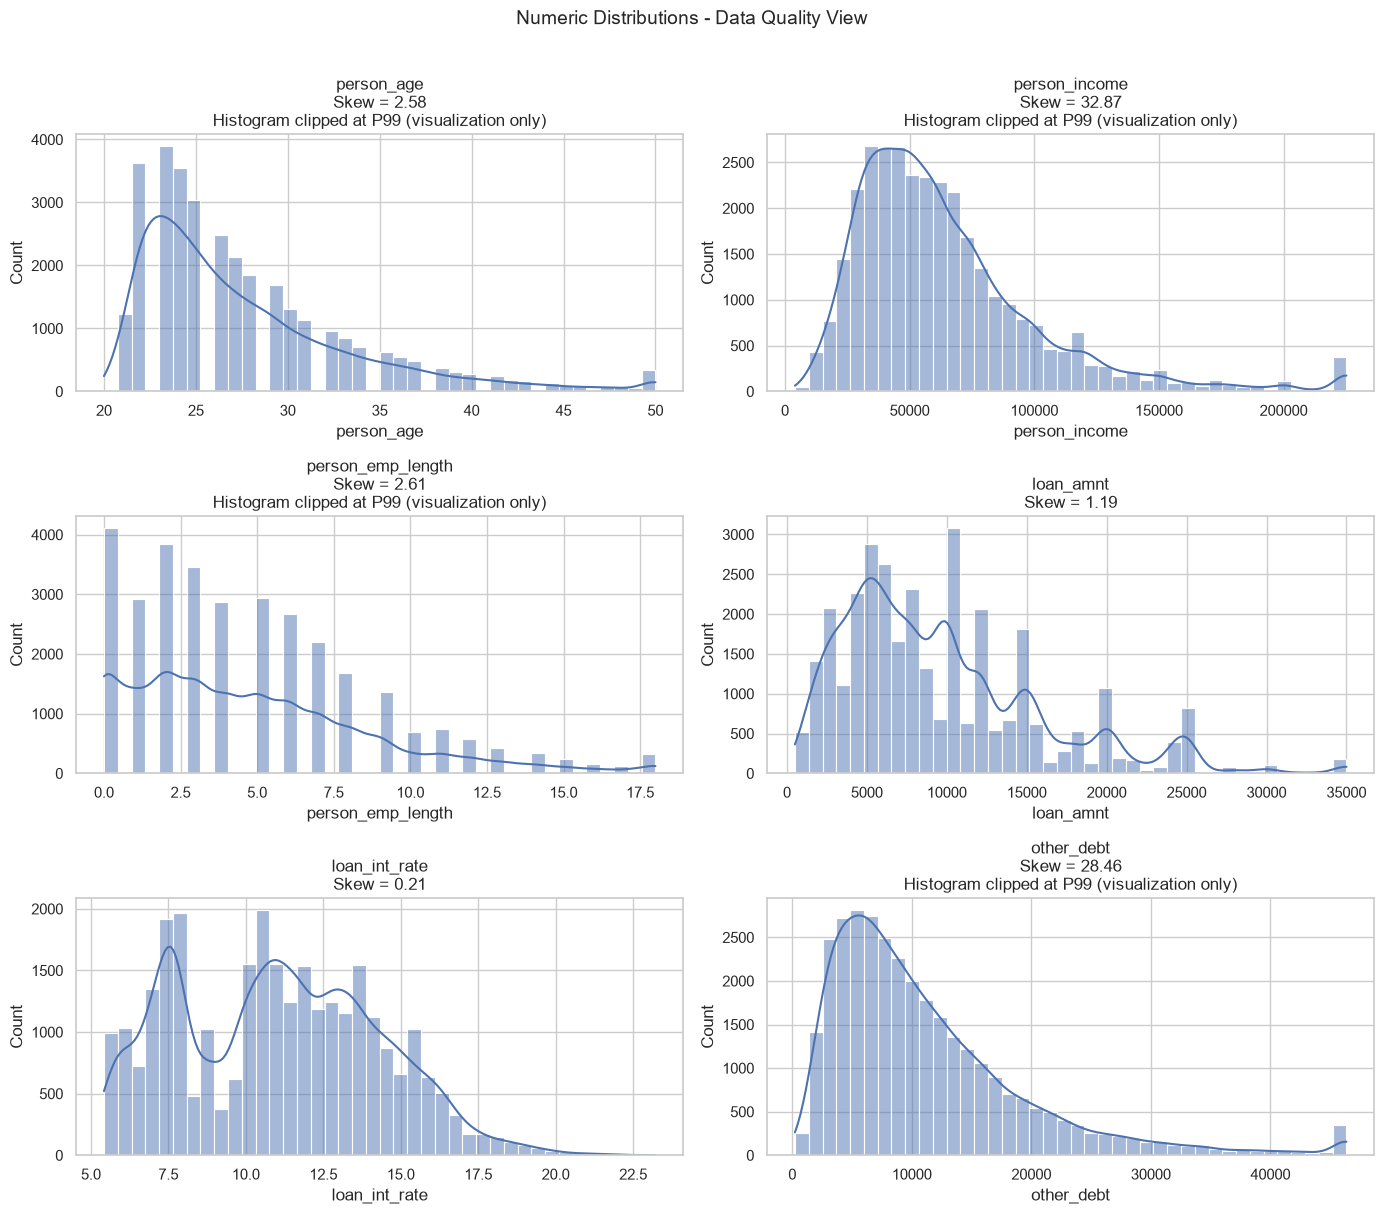

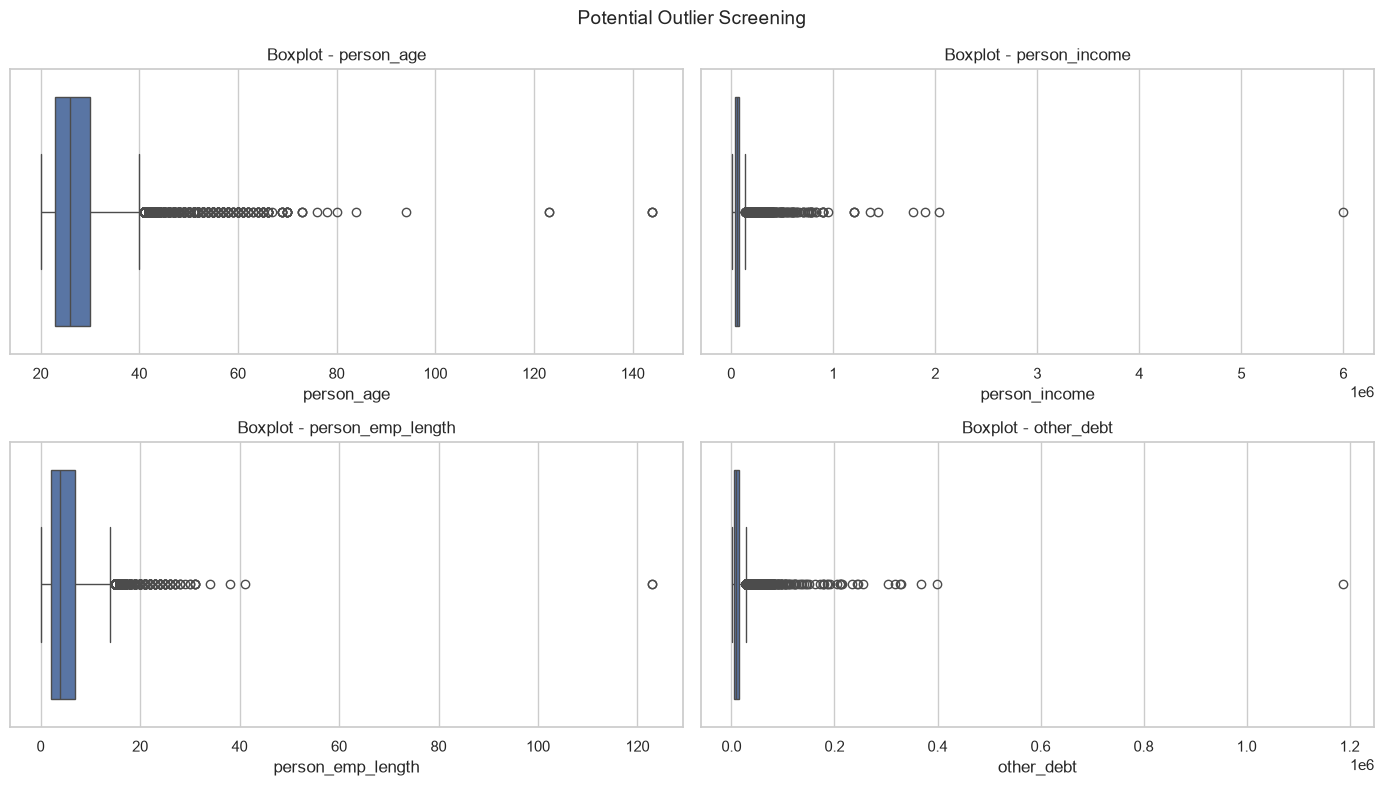

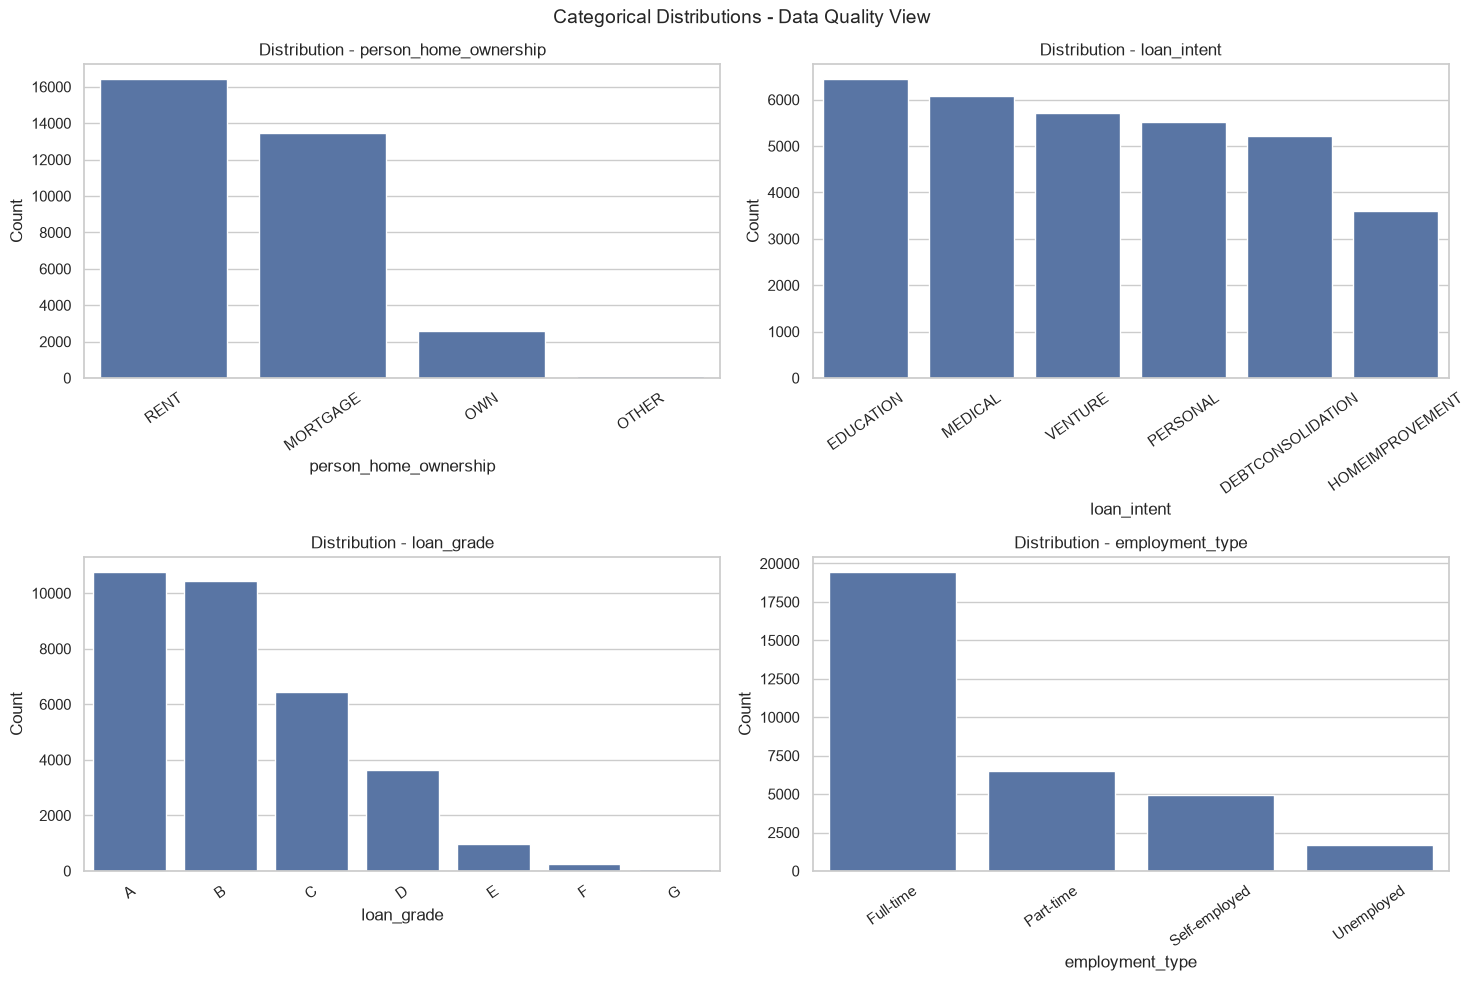


--- Numeric variables cần xem distribution sâu hơn ---


,column,missing_rate,min,median,95%,99%,max,skewness,distribution_flag
0,person_age,0.00%,20.0000,26.0000,40.0000,50.0000,144.0000,2.58,strong_skew
1,person_income,0.00%,"4,000.0000","55,000.0000","138,000.0000","225,200.0000","6,000,000.0000",32.87,strong_skew
2,person_emp_length,2.75%,0.0000,4.0000,13.0000,18.0000,123.0000,2.61,strong_skew
3,loan_amnt,0.00%,500.0000,"8,000.0000","24,000.0000","29,800.0000","35,000.0000",1.19,moderate_skew
4,loan_percent_income,0.00%,0.0000,0.1500,0.3800,0.5000,0.8300,1.06,moderate_skew
5,cb_person_cred_hist_length,0.00%,2.0000,4.0000,14.0000,17.0000,30.0000,1.66,moderate_skew
6,loan_to_income_ratio,0.00%,0.0008,0.1481,0.3788,0.5000,0.8300,1.07,moderate_skew
7,other_debt,0.00%,225.2074,"8,995.0706","27,965.0964","46,354.6458","1,187,998.9145",28.46,strong_skew
8,past_delinquencies,0.00%,0.0000,0.0000,2.0000,3.0000,6.0000,1.40,moderate_skew



Lưu ý:
- Histogram P99 clipping chỉ phục vụ visualization; df_raw không bị thay đổi.
- Skew/boxplot không đủ để kết luận một điểm là invalid.
- Quyết định keep / clip / remove sẽ được thực hiện sau business-rule audit.


In [6]:
# 1.4 - Distribution sơ bộ cho từng nhóm biến

# ============================================================
# 1. Tóm tắt distribution của toàn bộ numeric
# ============================================================

numeric_distribution_summary = (
    numeric_summary[["column", "missing_rate", "min", "median", "95%", "99%", "max", "skewness"]]
    .copy()
)

def classify_skew(skew_value):
    """Phân loại độ lệch của distribution (heuristic phục vụ audit)."""
    if pd.isna(skew_value):
        return "unknown"
    abs_skew = abs(skew_value)
    if abs_skew >= 2:
        return "strong_skew"
    if abs_skew >= 1:
        return "moderate_skew"
    return "roughly_symmetric"

numeric_distribution_summary["distribution_flag"] = (
    numeric_distribution_summary["skewness"].apply(classify_skew)
)

print("=" * 85)
print("NUMERIC DISTRIBUTION SUMMARY")
print("=" * 85)

display(
    numeric_distribution_summary.style.format({
        "missing_rate": "{:.2%}", "min": "{:,.4f}", "median": "{:,.4f}",
        "95%": "{:,.4f}", "99%": "{:,.4f}", "max": "{:,.4f}", "skewness": "{:.2f}"
    })
)

# ============================================================
# 2. Chọn numeric variables quan trọng để plot & 3. Histogram
# ============================================================

numeric_plot_priority = ["person_age", "person_income", "person_emp_length", "loan_amnt", "loan_int_rate", "other_debt"]
numeric_plot_cols = [col for col in numeric_plot_priority if col in df_raw.columns]

n_cols = 2
n_rows = int(np.ceil(len(numeric_plot_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_plot_cols):
    series = df_raw[col].dropna()
    skew_value = series.skew()
    plot_series = series.copy()
    clipping_note = ""

    if abs(skew_value) >= 2:
        p99 = series.quantile(0.99)
        plot_series = series.clip(upper=p99)
        clipping_note = "\nHistogram clipped at P99 (visualization only)"

    sns.histplot(plot_series, bins=40, kde=True, ax=ax)
    ax.set_title(f"{col}\nSkew = {skew_value:.2f}{clipping_note}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

for ax in axes[len(numeric_plot_cols):]:
    ax.set_visible(False)

plt.suptitle("Numeric Distributions - Data Quality View", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ============================================================
# 4. Boxplot cho các biến nghi ngờ outlier
# ============================================================

outlier_plot_priority = ["person_age", "person_income", "person_emp_length", "other_debt"]
outlier_plot_cols = [col for col in outlier_plot_priority if col in df_raw.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.reshape(-1)

for ax, col in zip(axes, outlier_plot_cols):
    sns.boxplot(x=df_raw[col], ax=ax)
    ax.set_title(f"Boxplot - {col}")
    ax.set_xlabel(col)

for ax in axes[len(outlier_plot_cols):]:
    ax.set_visible(False)

plt.suptitle("Potential Outlier Screening", fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 5. Categorical distribution
# ============================================================

categorical_plot_priority = ["person_home_ownership", "loan_intent", "loan_grade", "employment_type"]
categorical_plot_cols = [col for col in categorical_plot_priority if col in df_raw.columns]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.reshape(-1)

for ax, col in zip(axes, categorical_plot_cols):
    order = df_raw[col].value_counts().index
    sns.countplot(data=df_raw, x=col, order=order, ax=ax)
    ax.set_title(f"Distribution - {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=35)

for ax in axes[len(categorical_plot_cols):]:
    ax.set_visible(False)

plt.suptitle("Categorical Distributions - Data Quality View", fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 6. Tổng hợp các dấu hiệu cần mang sang audit sâu
# ============================================================

distribution_review = (
    numeric_distribution_summary.loc[
        numeric_distribution_summary["distribution_flag"].isin(["strong_skew", "moderate_skew"])
        & (numeric_distribution_summary["column"] != TARGET_COL)
    ]
    .copy()
    .reset_index(drop=True)
)

print("\n--- Numeric variables cần xem distribution sâu hơn ---")
display(
    distribution_review.style.format({
        "missing_rate": "{:.2%}", "min": "{:,.4f}", "median": "{:,.4f}",
        "95%": "{:,.4f}", "99%": "{:,.4f}", "max": "{:,.4f}", "skewness": "{:.2f}"
    })
)

print("\nLưu ý:")
print("- Histogram P99 clipping chỉ phục vụ visualization; df_raw không bị thay đổi.")
print("- Skew/boxplot không đủ để kết luận một điểm là invalid.")
print("- Quyết định keep / clip / remove sẽ được thực hiện sau business-rule audit.")

In [7]:
# 1.5 - Data Dictionary nháp

# ============================================================
# 1. Load Data Dictionary từ workbook gốc
# ============================================================

dictionary_sheet_name = globals().get("DICTIONARY_SHEET_NAME", "Data Dictionary")

source_dictionary = pd.read_excel(
    RAW_DATA_PATH,
    sheet_name=dictionary_sheet_name,
    engine="openpyxl",
)

source_dictionary.columns = [
    str(col).strip().lower().replace(" ", "_")
    for col in source_dictionary.columns
]

required_dictionary_cols = {"column_name", "description"}
missing_dictionary_cols = required_dictionary_cols - set(source_dictionary.columns)

if missing_dictionary_cols:
    raise ValueError(f"Data Dictionary sheet thiếu các cột: {sorted(missing_dictionary_cols)}")

source_dictionary = (
    source_dictionary[["column_name", "description"]]
    .rename(columns={"description": "business_meaning"})
    .copy()
)

# ============================================================
# 2. Kiểm tra coverage của dictionary
# ============================================================

raw_columns = set(df_raw.columns)
dictionary_columns = set(source_dictionary["column_name"])

missing_in_dictionary = sorted(raw_columns - dictionary_columns)
extra_in_dictionary = sorted(dictionary_columns - raw_columns)

print("Columns thiếu trong Data Dictionary:", missing_in_dictionary)
print("Columns có trong Dictionary nhưng không có trong dataset:", extra_in_dictionary)

# ============================================================
# 3. Business variable type overrides & 4. Expected domains
# ============================================================

VARIABLE_TYPE_OVERRIDES = {
    "client_ID": "identifier",
    "loan_status": "binary target",
    "loan_grade": "ordinal categorical",
    "cb_person_default_on_file": "binary categorical",
    "gender": "binary categorical",
    "loan_percent_income": "numeric ratio",
    "loan_to_income_ratio": "numeric ratio",
    "debt_to_income_ratio": "numeric ratio",
    "credit_utilization_ratio": "numeric ratio",
    "city_latitude": "numeric geographic",
    "city_longitude": "numeric geographic",
    "open_accounts": "count numeric",
    "past_delinquencies": "count numeric",
    "loan_term_months": "discrete numeric",
}

EXPECTED_DOMAINS = {
    "person_home_ownership": "Observed: RENT, OWN, MORTGAGE, OTHER",
    "loan_grade": "Expected: A, B, C, D, E, F, G",
    "loan_status": "Expected: 0 = non-default, 1 = default",
    "cb_person_default_on_file": "Expected: Y, N",
    "gender": "Observed: Male, Female",
    "marital_status": "Observed: Single, Married, Divorced, Widowed",
    "education_level": "Observed: High School, Bachelor, Master, PhD",
    "employment_type": "Observed: Full-time, Part-time, Self-employed, Unemployed",
    "loan_term_months": "Expected: 12, 24, 36, 60 months",
    "credit_utilization_ratio": "Expected: [0, 1]",
}

# ============================================================
# 5. Hàm lấy observed domain
# ============================================================

def get_observed_domain(column: str) -> str:
    """Trả về miền giá trị quan sát được trong raw dataset."""
    series = df_raw[column]
    if column in EXPECTED_DOMAINS:
        return EXPECTED_DOMAINS[column]

    if pd.api.types.is_numeric_dtype(series):
        min_value = series.min(skipna=True)
        max_value = series.max(skipna=True)
        return f"Observed range: {min_value:g} to {max_value:g}"

    values = series.dropna().astype(str).unique().tolist()
    if len(values) <= 20:
        return "Observed: " + ", ".join(values)
    return f"Observed cardinality: {len(values):,}"

# ============================================================
# 6. Leakage notes & 7. Audit notes
# ============================================================

LEAKAGE_NOTES = {
    "loan_status": "TARGET. Không được sử dụng làm input feature.",
    "loan_grade": (
        "Potential leakage: loan_grade có thể là output của underwriting/risk assessment trước đó. "
        "Primary Model nên loại feature này cho đến khi hoàn thành leakage audit."
    ),
    "loan_int_rate": (
        "Potential leakage: interest rate có thể được xác định bởi underwriting sau khi đánh giá risk. "
        "Cần xác minh feature availability tại thời điểm application."
    ),
}

age_invalid_count = 0
if "person_age" in df_raw.columns:
    age_invalid_count = int(((df_raw["person_age"] < 20) | (df_raw["person_age"] > 100)).sum())

lti_corr = np.nan
if {"loan_percent_income", "loan_to_income_ratio"}.issubset(df_raw.columns):
    lti_corr = df_raw["loan_percent_income"].corr(df_raw["loan_to_income_ratio"])

AUDIT_NOTES = {
    "client_ID": "Unique identifier; chỉ dùng tracking/join, không train trực tiếp.",
    "person_age": (
        f"Có {age_invalid_count:,} giá trị ngoài screening range 20–100; observed max = "
        f"{df_raw['person_age'].max():g}. Cần business-rule cleaning."
    ),
    "person_income": "Phân phối long-tail mạnh; max cao hơn rất nhiều so với P99. Cần outlier audit, không tự động xóa.",
    "person_emp_length": (
        f"Missing = {df_raw['person_emp_length'].isna().sum():,} "
        f"({df_raw['person_emp_length'].isna().mean():.2%}); observed max = "
        f"{df_raw['person_emp_length'].max():g}. Cần kiểm tra employment_length so với age."
    ),
    "person_home_ownership": (
        "Source description liệt kê RENT/OWN/MORTGAGE nhưng raw data còn có category OTHER; "
        "cần giữ lại discrepancy này trong Data Quality Report."
    ),
    "loan_int_rate": (
        f"Missing = {df_raw['loan_int_rate'].isna().sum():,} "
        f"({df_raw['loan_int_rate'].isna().mean():.2%}). Chưa impute ở Data Audit."
    ),
    "loan_percent_income": (
        "Potential redundancy với loan_to_income_ratio"
        + (f" (corr = {lti_corr:.4f})." if pd.notna(lti_corr) else ".")
        + " Không nên giữ cả hai một cách vô thức."
    ),
    "loan_to_income_ratio": (
        "Được suy ra trực tiếp từ loan_amnt / person_income. "
        "Potential redundancy với loan_percent_income"
        + (f" (corr = {lti_corr:.4f})." if pd.notna(lti_corr) else ".")
    ),
    "other_debt": (
        "Theo source dictionary đây là simulated/enriched feature. "
        "Distribution long-tail và có giá trị cực lớn; cần outlier/provenance audit."
    ),
    "gender": "Sensitive attribute. Nên dùng cho fairness audit; cần cân nhắc kỹ trước khi đưa vào Primary Model.",
    "country": "Geographic feature; có thể đóng vai trò proxy. Cần fairness/proxy review trước modeling.",
    "state": "Geographic feature; kiểm tra sample size và proxy risk trước modeling.",
    "city": "Geographic feature; ưu tiên EDA/dashboard. Có nguy cơ học geographic proxy/overfitting.",
    "city_latitude": "Geographic coordinate; phù hợp validation/map hơn là core credit-risk feature.",
    "city_longitude": "Geographic coordinate; phù hợp validation/map hơn là core credit-risk feature.",
    "loan_status": "Target: 0 = non-default, 1 = default.",
}

# ============================================================
# 8-14. Merge schema, hoàn thiện dictionary và sắp xếp cột
# ============================================================

schema_for_dictionary = schema_summary.rename(columns={"column": "column_name"}).copy()

data_dictionary = schema_for_dictionary.merge(source_dictionary, on="column_name", how="left")

data_dictionary["variable_type"] = data_dictionary.apply(
    lambda row: VARIABLE_TYPE_OVERRIDES.get(row["column_name"], row["variable_type"]), axis=1
)

data_dictionary["allowed_values_or_range"] = data_dictionary["column_name"].map(get_observed_domain)
data_dictionary["leakage_note"] = data_dictionary["column_name"].map(LEAKAGE_NOTES).fillna("")
data_dictionary["audit_note"] = data_dictionary["column_name"].map(AUDIT_NOTES).fillna("")

column_order = {col: idx for idx, col in enumerate(df_raw.columns)}
data_dictionary["_column_order"] = data_dictionary["column_name"].map(column_order)

data_dictionary = (
    data_dictionary.sort_values("_column_order")
    .drop(columns="_column_order")
    .reset_index(drop=True)
)

data_dictionary = data_dictionary[[
    "column_name", "dtype", "variable_type", "business_meaning",
    "allowed_values_or_range", "missing_rate", "unique_count",
    "is_target", "is_identifier", "leakage_note", "audit_note",
]]

# ============================================================
# 15. Validation & 16-17. Hiển thị Data Dictionary
# ============================================================

if len(data_dictionary) != len(df_raw.columns):
    raise ValueError("Số dòng Data Dictionary không khớp số cột dataset.")

if data_dictionary["business_meaning"].isna().any():
    missing_meaning = data_dictionary.loc[data_dictionary["business_meaning"].isna(), "column_name"].tolist()
    print("WARNING - Chưa có business meaning:", missing_meaning)

print("\n" + "=" * 100)
print("DRAFT DATA DICTIONARY")
print("=" * 100)

display(data_dictionary.style.format({"missing_rate": "{:.2%}"}))

dictionary_review = (
    data_dictionary.loc[
        data_dictionary["leakage_note"].ne("") | data_dictionary["audit_note"].ne("")
    ]
    .copy()
    .reset_index(drop=True)
)

print("\n--- Columns có leakage/audit note ---")
display(dictionary_review[["column_name", "variable_type", "leakage_note", "audit_note"]])

Columns thiếu trong Data Dictionary: []
Columns có trong Dictionary nhưng không có trong dataset: []

DRAFT DATA DICTIONARY


,column_name,dtype,variable_type,business_meaning,allowed_values_or_range,missing_rate,unique_count,is_target,is_identifier,leakage_note,audit_note
0,client_ID,str,identifier,Unique identifier for each client,"Observed cardinality: 32,581",0.00%,32581,False,True,,"Unique identifier; chỉ dùng tracking/join, không train trực tiếp."
1,person_age,int64,numeric,Age of the applicant (years),Observed range: 20 to 144,0.00%,58,False,False,,Có 5 giá trị ngoài screening range 20–100; observed max = 144. Cần business-rule cleaning.
2,person_income,int64,numeric,Annual income of the applicant (USD),Observed range: 4000 to 6e+06,0.00%,4295,False,False,,"Phân phối long-tail mạnh; max cao hơn rất nhiều so với P99. Cần outlier audit, không tự động xóa."
3,person_home_ownership,str,other,Home ownership status (RENT/OWN/MORTGAGE),"Observed: RENT, OWN, MORTGAGE, OTHER",0.00%,4,False,False,,Source description liệt kê RENT/OWN/MORTGAGE nhưng raw data còn có category OTHER; cần giữ lại discrepancy này trong Data Quality Report.
4,person_emp_length,float64,numeric,Employment length (years),Observed range: 0 to 123,2.75%,36,False,False,,Missing = 895 (2.75%); observed max = 123. Cần kiểm tra employment_length so với age.
5,loan_intent,str,other,"Purpose of the loan (PERSONAL, MEDICAL, EDUCATION, etc.)","Observed: PERSONAL, EDUCATION, MEDICAL, VENTURE, HOMEIMPROVEMENT, DEBTCONSOLIDATION",0.00%,6,False,False,,
6,loan_grade,str,ordinal categorical,Credit grade assigned to the loan (A–G),"Expected: A, B, C, D, E, F, G",0.00%,7,False,False,Potential leakage: loan_grade có thể là output của underwriting/risk assessment trước đó. Primary Model nên loại feature này cho đến khi hoàn thành leakage audit.,
7,loan_amnt,int64,numeric,Requested loan amount (USD),Observed range: 500 to 35000,0.00%,753,False,False,,
8,loan_int_rate,float64,numeric,Loan interest rate (%),Observed range: 5.42 to 23.22,9.56%,348,False,False,Potential leakage: interest rate có thể được xác định bởi underwriting sau khi đánh giá risk. Cần xác minh feature availability tại thời điểm application.,"Missing = 3,116 (9.56%). Chưa impute ở Data Audit."
9,loan_status,int64,binary target,"Loan repayment status (0 = non-default, 1 = default)","Expected: 0 = non-default, 1 = default",0.00%,2,True,False,TARGET. Không được sử dụng làm input feature.,"Target: 0 = non-default, 1 = default."



--- Columns có leakage/audit note ---


,column_name,variable_type,leakage_note,audit_note
0,client_ID,identifier,,"Unique identifier; chỉ dùng tracking/join, khô..."
1,person_age,numeric,,Có 5 giá trị ngoài screening range 20–100; obs...
2,person_income,numeric,,Phân phối long-tail mạnh; max cao hơn rất nhiề...
3,person_home_ownership,other,,Source description liệt kê RENT/OWN/MORTGAGE n...
4,person_emp_length,numeric,,Missing = 895 (2.75%); observed max = 123. Cần...
5,loan_grade,ordinal categorical,Potential leakage: loan_grade có thể là output...,
6,loan_int_rate,numeric,Potential leakage: interest rate có thể được x...,"Missing = 3,116 (9.56%). Chưa impute ở Data Au..."
7,loan_status,binary target,TARGET. Không được sử dụng làm input feature.,"Target: 0 = non-default, 1 = default."
8,loan_percent_income,numeric ratio,,Potential redundancy với loan_to_income_ratio ...
9,gender,binary categorical,,Sensitive attribute. Nên dùng cho fairness aud...


## Section 2 - 2.2 Duplicate

Theo kế hoạch cần kiểm tra **Duplicate client_ID** và **Duplicate rows**. Dataset hiện tại được ghi chú là không có duplicate, nhưng vẫn phải có validation tự động.

In [8]:
# 2.1 - Kiem tra duplicate rows
duplicate_row_mask = df_raw.duplicated(keep=False)
duplicate_row_count = int(duplicate_row_mask.sum())
duplicate_row_rate = duplicate_row_count / len(df_raw)
duplicate_rows_sample = df_raw.loc[duplicate_row_mask].head(10).copy()
duplicate_row_groups = (
    df_raw.loc[duplicate_row_mask]
    .value_counts(dropna=False)
    .reset_index(name="duplicate_group_size")
    .sort_values("duplicate_group_size", ascending=False)
)
duplicate_row_recommendation = (
    "Khong phat hien duplicate row; khong can xu ly."
    if duplicate_row_count == 0 else
    "Can review cum duplicate va chi drop sau khi co quyet dinh nghiep vu."
)
duplicate_row_summary = pd.DataFrame([{
    "check": "duplicate_rows",
    "affected_rows": duplicate_row_count,
    "rate": duplicate_row_rate,
    "recommendation": duplicate_row_recommendation,
}])
print(f"Duplicate rows: {duplicate_row_count:,}/{len(df_raw):,} ({duplicate_row_rate:.2%})")
print(duplicate_row_recommendation)
display(duplicate_row_summary.style.format({"rate": "{:.2%}"}))
if duplicate_row_count > 0:
    print("\n--- Sample duplicate rows ---")
    display(duplicate_rows_sample)
    print("\n--- Duplicate groups ---")
    display(duplicate_row_groups.head(10))


Duplicate rows: 0/32,581 (0.00%)
Khong phat hien duplicate row; khong can xu ly.


,check,affected_rows,rate,recommendation
0,duplicate_rows,0,0.00%,Khong phat hien duplicate row; khong can xu ly.


In [9]:
# 2.2 - Kiem tra duplicate client_ID
id_col = globals().get("ID_COL", "client_ID")
if id_col in df_raw.columns:
    duplicate_client_mask = df_raw[id_col].duplicated(keep=False)
    duplicate_client_row_count = int(duplicate_client_mask.sum())
    duplicate_client_count = int(df_raw.loc[duplicate_client_mask, id_col].nunique(dropna=True))
    duplicate_client_rate = duplicate_client_row_count / len(df_raw)
    duplicate_client_ids = df_raw.loc[duplicate_client_mask, id_col].value_counts(dropna=False).reset_index()
    duplicate_client_ids.columns = [id_col, "row_count"]
    duplicate_client_sample = df_raw.loc[duplicate_client_mask].sort_values(id_col).head(20).copy()
    duplicate_client_recommendation = (
        "client_ID la duy nhat; dataset co the xem la customer-level hoac loan-level 1 dong/khach."
        if duplicate_client_row_count == 0 else
        "Co client_ID lap lai; can xac nhan dataset loan-level hay loi trung ho so."
    )
else:
    duplicate_client_row_count = duplicate_client_count = 0
    duplicate_client_rate = 0
    duplicate_client_ids = pd.DataFrame(columns=[id_col, "row_count"])
    duplicate_client_sample = pd.DataFrame()
    duplicate_client_recommendation = f"Khong co cot {id_col}; khong ket luan duplicate client."
duplicate_client_summary = pd.DataFrame([{
    "check": "duplicate_client_id",
    "id_col": id_col if id_col in df_raw.columns else None,
    "duplicate_id_count": duplicate_client_count,
    "affected_rows": duplicate_client_row_count,
    "rate": duplicate_client_rate,
    "recommendation": duplicate_client_recommendation,
}])
print(f"Duplicate {id_col}: {duplicate_client_count:,} ID, {duplicate_client_row_count:,} rows ({duplicate_client_rate:.2%})")
print(duplicate_client_recommendation)
display(duplicate_client_summary.style.format({"rate": "{:.2%}"}))
if duplicate_client_row_count > 0:
    print("\n--- Duplicate client_ID counts ---")
    display(duplicate_client_ids.head(20))
    print("\n--- Sample duplicate client_ID rows ---")
    display(duplicate_client_sample)


Duplicate client_ID: 0 ID, 0 rows (0.00%)
client_ID la duy nhat; dataset co the xem la customer-level hoac loan-level 1 dong/khach.


,check,id_col,duplicate_id_count,affected_rows,rate,recommendation
0,duplicate_client_id,client_ID,0,0,0.00%,client_ID la duy nhat; dataset co the xem la customer-level hoac loan-level 1 dong/khach.


## Section 3 - 2.3 Missing Values

Hai vấn đề đã biết trong kế hoạch:
- `person_emp_length` thiếu khoảng 2.75%.
- `loan_int_rate` thiếu khoảng 9.56%.

Không vội `fillna(mean)`. Cần thử/ghi nhận các hướng: median imputation, group median, missing indicator.

In [10]:
# 3.1 - Missing values overview

# ============================================================
# 1. Missing values that pandas recognizes as NA/NaN
# ============================================================

n_rows = len(df_raw)

missing_overview_all = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "non_missing_count": df_raw.notna().sum().values,
    "missing_count": df_raw.isna().sum().values,
})

missing_overview_all["missing_rate"] = (
    missing_overview_all["missing_count"] / n_rows
)

missing_overview_all = (
    missing_overview_all
    .sort_values(
        ["missing_rate", "missing_count", "column"],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

missing_summary = (
    missing_overview_all
    .loc[missing_overview_all["missing_count"] > 0]
    .copy()
    .reset_index(drop=True)
)

missing_columns = missing_summary["column"].tolist()

# ============================================================
# 2. Check encoded missing tokens in text/category-like columns
# ============================================================

encoded_missing_tokens = {
    "", "na", "n/a", "nan", "null", "none",
    "unknown", "missing", "?", "-"
}

encoded_missing_records = []

for column in df_raw.select_dtypes(
    include=["object", "category", "string"]
).columns:
    normalized = df_raw[column].astype("string").str.strip().str.lower()
    token_mask = normalized.isin(encoded_missing_tokens)
    token_count = int(token_mask.sum())

    if token_count == 0:
        continue

    encoded_missing_records.append({
        "column": column,
        "encoded_missing_count": token_count,
        "encoded_missing_rate": token_count / n_rows,
        "tokens_found": sorted(
            normalized.loc[token_mask].dropna().unique().tolist()
        ),
    })

encoded_missing_summary = pd.DataFrame(encoded_missing_records)

if not encoded_missing_summary.empty:
    encoded_missing_summary = (
        encoded_missing_summary
        .sort_values(
            ["encoded_missing_rate", "column"],
            ascending=[False, True]
        )
        .reset_index(drop=True)
    )

# ============================================================
# 3. Confirm known missing issues from the audit plan
# ============================================================

known_missing_expectations = {
    "person_emp_length": 0.0275,
    "loan_int_rate": 0.0956,
}

known_missing_records = []

for column, expected_rate in known_missing_expectations.items():
    if column not in df_raw.columns:
        known_missing_records.append({
            "column": column,
            "missing_count": np.nan,
            "missing_rate": np.nan,
            "expected_rate_from_plan": expected_rate,
            "delta_vs_plan": np.nan,
            "status": "column_not_found",
        })
        continue

    actual_count = int(df_raw[column].isna().sum())
    actual_rate = actual_count / n_rows

    known_missing_records.append({
        "column": column,
        "missing_count": actual_count,
        "missing_rate": actual_rate,
        "expected_rate_from_plan": expected_rate,
        "delta_vs_plan": actual_rate - expected_rate,
        "status": (
            "match_plan"
            if abs(actual_rate - expected_rate) <= 0.002
            else "review_delta"
        ),
    })

known_missing_check = pd.DataFrame(known_missing_records)

# ============================================================
# 4. Audit notes for reporting and later preprocessing design
# ============================================================

known_missing_columns = [
    col for col in known_missing_expectations
    if col in df_raw.columns
]

unexpected_missing_columns = sorted(
    set(missing_columns) - set(known_missing_columns)
)

missing_audit_notes = []

if missing_summary.empty:
    missing_audit_notes.append(
        "No pandas NA/NaN missing values found in df_raw."
    )
else:
    missing_audit_notes.append(
        f"Found {len(missing_summary)} columns with pandas NA/NaN missing values."
    )

if unexpected_missing_columns:
    missing_audit_notes.append(
        "Columns with missing values beyond the two expected issues: "
        + ", ".join(unexpected_missing_columns)
    )
else:
    missing_audit_notes.append(
        "No extra pandas NA/NaN missing columns beyond "
        "person_emp_length and loan_int_rate."
    )

if encoded_missing_summary.empty:
    missing_audit_notes.append(
        "No encoded string-missing tokens found among checked "
        "categorical/text columns."
    )
else:
    missing_audit_notes.append(
        "Encoded string-missing tokens found; review "
        "encoded_missing_summary before preprocessing."
    )

missing_audit_notes.append(
    "Data Audit records missing patterns only; imputation must be "
    "implemented inside the train/CV pipeline."
)

# ============================================================
# 5. Display results
# ============================================================

print("=" * 85)
print("MISSING VALUES OVERVIEW")
print("=" * 85)
print(f"Rows checked: {n_rows:,}")
print(f"Columns checked: {df_raw.shape[1]:,}")
print(f"Columns with pandas NA/NaN: {len(missing_summary):,}")

print("\n--- Missing summary: columns with missing_rate > 0 ---")
if missing_summary.empty:
    print("No pandas NA/NaN missing values found.")
else:
    display(
        missing_summary.style.format({
            "missing_rate": "{:.2%}"
        })
    )

print("\n--- Known missing checks from plan ---")
display(
    known_missing_check.style.format({
        "missing_rate": "{:.2%}",
        "expected_rate_from_plan": "{:.2%}",
        "delta_vs_plan": "{:+.2%}",
    })
)

print("\n--- Encoded string-missing token check ---")
if encoded_missing_summary.empty:
    print("No encoded string-missing tokens found.")
else:
    display(
        encoded_missing_summary.style.format({
            "encoded_missing_rate": "{:.2%}"
        })
    )

print("\n--- Missing audit notes ---")
for note in missing_audit_notes:
    print(f"- {note}")

MISSING VALUES OVERVIEW
Rows checked: 32,581
Columns checked: 29
Columns with pandas NA/NaN: 2

--- Missing summary: columns with missing_rate > 0 ---


,column,dtype,non_missing_count,missing_count,missing_rate
0,loan_int_rate,float64,29465,3116,9.56%
1,person_emp_length,float64,31686,895,2.75%



--- Known missing checks from plan ---


,column,missing_count,missing_rate,expected_rate_from_plan,delta_vs_plan,status
0,person_emp_length,895,2.75%,2.75%,-0.00%,match_plan
1,loan_int_rate,3116,9.56%,9.56%,+0.00%,match_plan



--- Encoded string-missing token check ---
No encoded string-missing tokens found.

--- Missing audit notes ---
- Found 2 columns with pandas NA/NaN missing values.
- No extra pandas NA/NaN missing columns beyond person_emp_length and loan_int_rate.
- No encoded string-missing tokens found among checked categorical/text columns.
- Data Audit records missing patterns only; imputation must be implemented inside the train/CV pipeline.


In [11]:
# 3.2 - Phân tích missing của person_emp_length

EMP_COL = "person_emp_length"

if EMP_COL not in df_raw.columns:
    raise KeyError(f"Không tìm thấy cột '{EMP_COL}' trong df_raw.")

# ============================================================
# 1. Tạo cờ missing tạm thời để audit
# ============================================================

emp_audit = df_raw.assign(
    is_person_emp_length_missing=df_raw[EMP_COL].isna()
)

emp_audit["emp_missing_group"] = np.where(
    emp_audit["is_person_emp_length_missing"],
    "Missing",
    "Observed"
)

emp_missing_count = int(
    emp_audit["is_person_emp_length_missing"].sum()
)

emp_missing_rate = (
    emp_missing_count / len(emp_audit)
)

emp_missing_overview = pd.DataFrame([{
    "column": EMP_COL,
    "missing_count": emp_missing_count,
    "missing_rate": emp_missing_rate,
    "observed_count": int(emp_audit[EMP_COL].notna().sum()),
    "observed_median": emp_audit[EMP_COL].median(),
}])

# ============================================================
# 2. So sánh nhóm Missing và Observed
# ============================================================

emp_agg = {
    "rows": ("is_person_emp_length_missing", "size"),
    "person_age_median": ("person_age", "median"),
    "person_income_median": ("person_income", "median"),
    "loan_amnt_median": ("loan_amnt", "median"),
}

if TARGET_COL in emp_audit.columns:
    emp_agg["default_rate"] = (TARGET_COL, "mean")

emp_missing_group_summary = (
    emp_audit
    .groupby("emp_missing_group", sort=False)
    .agg(**emp_agg)
    .reset_index()
)

emp_missing_group_summary["row_share"] = (
    emp_missing_group_summary["rows"] / len(emp_audit)
)

# ============================================================
# 3. Kiểm tra missing theo các nhóm khách hàng
# ============================================================

emp_group_profiles = {}

for group_col in [
    "person_home_ownership",
    "loan_intent",
]:
    if group_col not in emp_audit.columns:
        continue

    profile = (
        emp_audit
        .groupby(group_col, dropna=False)
        .agg(
            rows=(EMP_COL, "size"),
            missing_count=(
                "is_person_emp_length_missing",
                "sum"
            ),
            missing_rate=(
                "is_person_emp_length_missing",
                "mean"
            ),
            observed_emp_median=(
                EMP_COL,
                "median"
            ),
        )
        .reset_index()
        .sort_values(
            ["missing_rate", "rows"],
            ascending=[False, False]
        )
        .reset_index(drop=True)
    )

    emp_group_profiles[group_col] = profile

# ============================================================
# 4. Kiểm tra chênh lệch default rate
# ============================================================

emp_default_rate_gap = np.nan

if "default_rate" in emp_missing_group_summary.columns:
    default_rates = (
        emp_missing_group_summary
        .set_index("emp_missing_group")["default_rate"]
    )

    if {"Missing", "Observed"}.issubset(default_rates.index):
        emp_default_rate_gap = (
            default_rates["Missing"]
            - default_rates["Observed"]
        )

# ============================================================
# 5. Audit notes
# ============================================================

emp_audit_notes = [
    (
        "Không sửa trực tiếp df_raw; cờ missing chỉ được tạo "
        "trong DataFrame tạm emp_audit."
    ),
    (
        "Median là baseline hợp lý vì person_emp_length "
        "có thể có extreme values và median robust hơn mean."
    ),
    (
        "Có thể thử missing indicator vì bản thân việc thiếu "
        "employment length có thể mang thông tin."
    ),
    (
        "Group median chỉ nên dùng nếu nhóm đủ lớn, ổn định "
        "và cải thiện kết quả trong cross-validation."
    ),
    (
        "Mọi thống kê imputation sau này phải được fit "
        "chỉ trên training fold để tránh leakage."
    ),
]

# ============================================================
# 6. Display results
# ============================================================

print("=" * 85)
print("PERSON_EMP_LENGTH MISSING AUDIT")
print("=" * 85)

display(
    emp_missing_overview.style.format({
        "missing_rate": "{:.2%}",
        "observed_median": "{:.2f}",
    })
)

print("\n--- Missing vs Observed ---")
format_dict = {
    "row_share": "{:.2%}",
    "person_age_median": "{:.2f}",
    "person_income_median": "{:,.0f}",
    "loan_amnt_median": "{:,.0f}",
}

if "default_rate" in emp_missing_group_summary.columns:
    format_dict["default_rate"] = "{:.2%}"

display(
    emp_missing_group_summary.style.format(
        format_dict
    )
)

print("\n--- Missing pattern by customer groups ---")

for group_col, profile in emp_group_profiles.items():
    print(f"\nGroup by: {group_col}")

    display(
        profile.style.format({
            "missing_rate": "{:.2%}",
            "observed_emp_median": "{:.2f}",
        })
    )

if not pd.isna(emp_default_rate_gap):
    print(
        "\nDefault-rate gap "
        f"(Missing - Observed): "
        f"{emp_default_rate_gap:+.2%}"
    )

print("\n--- Audit notes ---")

for note in emp_audit_notes:
    print(f"- {note}")

PERSON_EMP_LENGTH MISSING AUDIT


,column,missing_count,missing_rate,observed_count,observed_median
0,person_emp_length,895,2.75%,31686,4.00



--- Missing vs Observed ---


,emp_missing_group,rows,person_age_median,person_income_median,loan_amnt_median,default_rate,row_share
0,Observed,31686,26.00,"56,000","8,000",21.54%,97.25%
1,Missing,895,25.00,"36,000","6,000",31.51%,2.75%



--- Missing pattern by customer groups ---

Group by: person_home_ownership


,person_home_ownership,rows,missing_count,missing_rate,observed_emp_median
0,OWN,2584,174,6.73%,4.00
1,MORTGAGE,13444,351,2.61%,5.00
2,RENT,16446,370,2.25%,3.00
3,OTHER,107,0,0.00%,3.00



Group by: loan_intent


,loan_intent,rows,missing_count,missing_rate,observed_emp_median
0,MEDICAL,6071,174,2.87%,4.00
1,VENTURE,5719,163,2.85%,4.00
2,DEBTCONSOLIDATION,5212,148,2.84%,4.00
3,PERSONAL,5521,152,2.75%,4.00
4,HOMEIMPROVEMENT,3605,95,2.64%,4.00
5,EDUCATION,6453,163,2.53%,4.00



Default-rate gap (Missing - Observed): +9.97%

--- Audit notes ---
- Không sửa trực tiếp df_raw; cờ missing chỉ được tạo trong DataFrame tạm emp_audit.
- Median là baseline hợp lý vì person_emp_length có thể có extreme values và median robust hơn mean.
- Có thể thử missing indicator vì bản thân việc thiếu employment length có thể mang thông tin.
- Group median chỉ nên dùng nếu nhóm đủ lớn, ổn định và cải thiện kết quả trong cross-validation.
- Mọi thống kê imputation sau này phải được fit chỉ trên training fold để tránh leakage.


In [12]:
# 3.3 - Phân tích missing của loan_int_rate

RATE_COL = "loan_int_rate"

if RATE_COL not in df_raw.columns:
    raise KeyError(f"Không tìm thấy cột '{RATE_COL}' trong df_raw.")

# ============================================================
# 1. Tạo cờ missing tạm thời
# ============================================================

rate_audit = df_raw.assign(
    is_loan_int_rate_missing=df_raw[RATE_COL].isna()
)

rate_audit["rate_missing_group"] = np.where(
    rate_audit["is_loan_int_rate_missing"],
    "Missing",
    "Observed"
)

rate_missing_count = int(
    rate_audit["is_loan_int_rate_missing"].sum()
)

rate_missing_rate = (
    rate_missing_count / len(rate_audit)
)

rate_missing_overview = pd.DataFrame([{
    "column": RATE_COL,
    "missing_count": rate_missing_count,
    "missing_rate": rate_missing_rate,
    "observed_count": int(rate_audit[RATE_COL].notna().sum()),
    "observed_median": rate_audit[RATE_COL].median(),
}])

# ============================================================
# 2. So sánh nhóm Missing và Observed
# ============================================================

rate_agg = {
    "rows": ("is_loan_int_rate_missing", "size"),
    "person_income_median": (
        "person_income",
        "median"
    ),
    "loan_amnt_median": (
        "loan_amnt",
        "median"
    ),
}

if TARGET_COL in rate_audit.columns:
    rate_agg["default_rate"] = (
        TARGET_COL,
        "mean"
    )

rate_missing_group_summary = (
    rate_audit
    .groupby("rate_missing_group", sort=False)
    .agg(**rate_agg)
    .reset_index()
)

rate_missing_group_summary["row_share"] = (
    rate_missing_group_summary["rows"]
    / len(rate_audit)
)

# ============================================================
# 3. Kiểm tra missing và median theo các nhóm liên quan
# ============================================================

rate_group_profiles = {}

for group_col in [
    "loan_intent",
    "loan_grade",
]:
    if group_col not in rate_audit.columns:
        continue

    profile = (
        rate_audit
        .groupby(group_col, dropna=False)
        .agg(
            rows=(RATE_COL, "size"),
            missing_count=(
                "is_loan_int_rate_missing",
                "sum"
            ),
            missing_rate=(
                "is_loan_int_rate_missing",
                "mean"
            ),
            observed_rate_median=(
                RATE_COL,
                "median"
            ),
        )
        .reset_index()
        .sort_values(
            ["missing_rate", "rows"],
            ascending=[False, False]
        )
        .reset_index(drop=True)
    )

    rate_group_profiles[group_col] = profile

# ============================================================
# 4. Kiểm tra chênh lệch default rate
# ============================================================

rate_default_rate_gap = np.nan

if "default_rate" in rate_missing_group_summary.columns:
    default_rates = (
        rate_missing_group_summary
        .set_index("rate_missing_group")["default_rate"]
    )

    if {"Missing", "Observed"}.issubset(default_rates.index):
        rate_default_rate_gap = (
            default_rates["Missing"]
            - default_rates["Observed"]
        )

# ============================================================
# 5. Leakage notes
# ============================================================

rate_audit_notes = [
    (
        "loan_int_rate có potential leakage vì lãi suất có thể "
        "được xác định sau hoặc trong quá trình underwriting."
    ),
    (
        "Không đưa loan_int_rate vào Primary Model cho đến khi "
        "xác minh feature availability tại application time."
    ),
    (
        "loan_grade chỉ được dùng ở đây để audit mối quan hệ; "
        "không nên dùng để impute loan_int_rate trong Primary Model."
    ),
    (
        "Nếu loan_int_rate được xác nhận là hợp lệ, baseline nên "
        "thử median + missing indicator trong train/CV pipeline."
    ),
    (
        "Group median theo loan_intent có thể thử vì loan_intent "
        "là thông tin application-time hợp lý hơn loan_grade."
    ),
]

# ============================================================
# 6. Display results
# ============================================================

print("=" * 85)
print("LOAN_INT_RATE MISSING AUDIT")
print("=" * 85)

display(
    rate_missing_overview.style.format({
        "missing_rate": "{:.2%}",
        "observed_median": "{:.2f}",
    })
)

print("\n--- Missing vs Observed ---")

format_dict = {
    "row_share": "{:.2%}",
    "person_income_median": "{:,.0f}",
    "loan_amnt_median": "{:,.0f}",
}

if "default_rate" in rate_missing_group_summary.columns:
    format_dict["default_rate"] = "{:.2%}"

display(
    rate_missing_group_summary.style.format(
        format_dict
    )
)

print("\n--- Missing pattern by related groups ---")

for group_col, profile in rate_group_profiles.items():
    print(f"\nGroup by: {group_col}")

    display(
        profile.style.format({
            "missing_rate": "{:.2%}",
            "observed_rate_median": "{:.2f}",
        })
    )

if not pd.isna(rate_default_rate_gap):
    print(
        "\nDefault-rate gap "
        f"(Missing - Observed): "
        f"{rate_default_rate_gap:+.2%}"
    )

print("\n--- Audit notes ---")

for note in rate_audit_notes:
    print(f"- {note}")


LOAN_INT_RATE MISSING AUDIT


,column,missing_count,missing_rate,observed_count,observed_median
0,loan_int_rate,3116,9.56%,29465,10.99



--- Missing vs Observed ---


,rate_missing_group,rows,person_income_median,loan_amnt_median,default_rate,row_share
0,Observed,29465,"55,000","8,000",21.94%,90.44%
1,Missing,3116,"55,640","8,000",20.67%,9.56%



--- Missing pattern by related groups ---

Group by: loan_intent


,loan_intent,rows,missing_count,missing_rate,observed_rate_median
0,MEDICAL,6071,620,10.21%,10.99
1,VENTURE,5719,566,9.90%,10.99
2,DEBTCONSOLIDATION,5212,509,9.77%,10.99
3,EDUCATION,6453,599,9.28%,10.99
4,PERSONAL,5521,507,9.18%,10.99
5,HOMEIMPROVEMENT,3605,315,8.74%,11.14



Group by: loan_grade


,loan_grade,rows,missing_count,missing_rate,observed_rate_median
0,F,241,27,11.20%,18.54
1,B,10451,1056,10.10%,10.99
2,C,6458,630,9.76%,13.48
3,A,10777,1003,9.31%,7.49
4,E,964,83,8.61%,16.82
5,D,3626,312,8.60%,15.31
6,G,64,5,7.81%,20.16



Default-rate gap (Missing - Observed): -1.27%

--- Audit notes ---
- loan_int_rate có potential leakage vì lãi suất có thể được xác định sau hoặc trong quá trình underwriting.
- Không đưa loan_int_rate vào Primary Model cho đến khi xác minh feature availability tại application time.
- loan_grade chỉ được dùng ở đây để audit mối quan hệ; không nên dùng để impute loan_int_rate trong Primary Model.
- Nếu loan_int_rate được xác nhận là hợp lệ, baseline nên thử median + missing indicator trong train/CV pipeline.
- Group median theo loan_intent có thể thử vì loan_intent là thông tin application-time hợp lý hơn loan_grade.


In [13]:
# 3.4 - So sánh các chiến lược xử lý missing ở mức thiết kế

# ============================================================
# 1. Hàm lấy thông tin missing từ kết quả cell 3.1
# ============================================================

def get_missing_issue(column: str) -> str:
    row = missing_summary.loc[
        missing_summary["column"] == column
    ]

    if row.empty:
        return (
            "No pandas NA/NaN detected "
            "in current audit."
        )

    count = int(row.iloc[0]["missing_count"])
    rate = float(row.iloc[0]["missing_rate"])

    return (
        f"{count:,} missing values "
        f"({rate:.2%})."
    )

# ============================================================
# 2. Action plan cho các missing issues đã biết
# ============================================================

missing_action_records = [
    {
        "column": "person_emp_length",
        "issue": get_missing_issue(
            "person_emp_length"
        ),
        "candidate_methods": (
            "Median | Group median | "
            "Median + missing indicator"
        ),
        "recommended_method": (
            "Median + missing indicator "
            "as baseline"
        ),
        "reason": (
            "Median is robust to extreme employment-length "
            "values. Missingness may itself carry information. "
            "Group median is only a candidate if groups are "
            "sufficiently large and stable."
        ),
        "validation_needed": (
            "Compare median, group median, and median + "
            "indicator inside train/CV only. Fit all "
            "imputation statistics on each training fold."
        ),
    },
    {
        "column": "loan_int_rate",
        "issue": get_missing_issue(
            "loan_int_rate"
        ),
        "candidate_methods": (
            "Exclude feature | Median | "
            "Group median by loan_intent | "
            "Median + missing indicator"
        ),
        "recommended_method": (
            "Exclude from Primary Model until leakage audit; "
            "if retained, use median + missing indicator "
            "as baseline"
        ),
        "reason": (
            "Interest rate may be determined during "
            "underwriting. Using loan_grade for imputation "
            "can introduce additional underwriting leakage."
        ),
        "validation_needed": (
            "First verify application-time availability in "
            "the leakage audit. If retained, compare "
            "imputation strategies inside train/CV. "
            "Do not use loan_grade for Primary Model "
            "imputation unless proven non-leaky."
        ),
    },
]

# ============================================================
# 3. Tự động bắt các missing column ngoài kế hoạch
# ============================================================

planned_columns = {
    record["column"]
    for record in missing_action_records
}

unexpected_columns = sorted(
    set(missing_columns) - planned_columns
)

for column in unexpected_columns:
    missing_action_records.append({
        "column": column,
        "issue": get_missing_issue(column),
        "candidate_methods": (
            "Median/mode | Group-based imputation | "
            "Missing indicator"
        ),
        "recommended_method": "Review required",
        "reason": (
            "Unexpected missing column found beyond "
            "the current audit plan."
        ),
        "validation_needed": (
            "Determine business meaning first, then "
            "validate the chosen method inside train/CV."
        ),
    })

# ============================================================
# 4. Tạo bảng missing action plan
# ============================================================

missing_action_plan = pd.DataFrame(
    missing_action_records
)

# ============================================================
# 5. Display
# ============================================================

print("=" * 85)
print("MISSING VALUE ACTION PLAN")
print("=" * 85)

display(missing_action_plan)

print("\nImportant:")
print(
    "- Đây là kế hoạch thiết kế, "
    "chưa phải preprocessing cuối cùng."
)
print(
    "- Không impute trực tiếp trên df_raw."
)
print(
    "- Imputer phải được fit trong training fold."
)
print(
    "- Quyết định cuối cùng phải dựa trên "
    "cross-validation và leakage audit."
)

MISSING VALUE ACTION PLAN


,column,issue,candidate_methods,recommended_method,reason,validation_needed
0,person_emp_length,895 missing values (2.75%).,Median | Group median | Median + missing indic...,Median + missing indicator as baseline,Median is robust to extreme employment-length ...,"Compare median, group median, and median + ind..."
1,loan_int_rate,"3,116 missing values (9.56%).",Exclude feature | Median | Group median by loa...,Exclude from Primary Model until leakage audit...,Interest rate may be determined during underwr...,First verify application-time availability in ...



Important:
- Đây là kế hoạch thiết kế, chưa phải preprocessing cuối cùng.
- Không impute trực tiếp trên df_raw.
- Imputer phải được fit trong training fold.
- Quyết định cuối cùng phải dựa trên cross-validation và leakage audit.


## Section 4 - 2.4 Outlier và Business Rules

Các outlier đã biết:
- `person_age = 144`
- `person_emp_length = 123`

Cần xây business rules, ví dụ `20 <= age <= 100` và `employment_length <= age - minimum_working_age`. Không mặc định xóa outlier; cần so sánh giữ lại, clip, hoặc loại bỏ.

In [14]:
# 4.1 - Định nghĩa business rules cho range validation

# ============================================================
# 1. Khai báo các cột và ngưỡng kiểm tra
# ============================================================

AGE_COL = "person_age"
EMP_COL = "person_emp_length"

age_min = 20
age_max = 100

# Giả định dùng để kiểm tra tính hợp lý dữ liệu,
# không phải khẳng định độ tuổi lao động theo pháp luật.
minimum_working_age = 14

required_columns = [AGE_COL, EMP_COL]
missing_rule_columns = [
    col for col in required_columns
    if col not in df_raw.columns
]

if missing_rule_columns:
    raise KeyError(
        "Không tìm thấy các cột cần kiểm tra: "
        + ", ".join(missing_rule_columns)
    )

# ============================================================
# 2. Định nghĩa business rules
# ============================================================

business_rules = pd.DataFrame([
    {
        "column": AGE_COL,
        "rule_name": "age_plausible_range",
        "rule_description": (
            f"{age_min} <= {AGE_COL} <= {age_max}. "
            "Đây là khoảng tuổi hợp lý dùng cho project, "
            "không phải giới hạn pháp lý chung."
        ),
        "severity": "error",
    },
    {
        "column": EMP_COL,
        "rule_name": "employment_non_negative",
        "rule_description": (
            f"{EMP_COL} >= 0 khi có dữ liệu."
        ),
        "severity": "error",
    },
    {
        "column": EMP_COL,
        "rule_name": "employment_consistent_with_age",
        "rule_description": (
            f"{EMP_COL} <= {AGE_COL} - {minimum_working_age}. "
            "Số năm làm việc không được lớn hơn số năm "
            "khách hàng có thể đã đi làm."
        ),
        "severity": "error",
    },
])

# ============================================================
# 3. Audit notes
# ============================================================

business_rule_notes = [
    (
        f"Khoảng tuổi [{age_min}, {age_max}] là project-specific "
        "plausibility rule (quy tắc kiểm tra tính hợp lý của project)."
    ),
    (
        f"minimum_working_age = {minimum_working_age} được chọn "
        "theo hướng bảo thủ để tránh đánh dấu quá nhiều "
        "employment history (lịch sử làm việc) có thể vẫn hợp lý."
    ),
    (
        "Business rules chỉ dùng để phát hiện dữ liệu đáng ngờ; "
        "không tự động sửa hoặc xóa dữ liệu ở bước Data Audit."
    ),
]

# ============================================================
# 4. Display
# ============================================================

print("=" * 85)
print("BUSINESS RULES - QUY TẮC NGHIỆP VỤ")
print("=" * 85)

display(business_rules)

print("\n--- Audit notes (ghi chú kiểm tra) ---")
for note in business_rule_notes:
    print(f"- {note}")

BUSINESS RULES - QUY TẮC NGHIỆP VỤ


,column,rule_name,rule_description,severity
0,person_age,age_plausible_range,20 <= person_age <= 100. Đây là khoảng tuổi hợ...,error
1,person_emp_length,employment_non_negative,person_emp_length >= 0 khi có dữ liệu.,error
2,person_emp_length,employment_consistent_with_age,person_emp_length <= person_age - 14. Số năm l...,error



--- Audit notes (ghi chú kiểm tra) ---
- Khoảng tuổi [20, 100] là project-specific plausibility rule (quy tắc kiểm tra tính hợp lý của project).
- minimum_working_age = 14 được chọn theo hướng bảo thủ để tránh đánh dấu quá nhiều employment history (lịch sử làm việc) có thể vẫn hợp lý.
- Business rules chỉ dùng để phát hiện dữ liệu đáng ngờ; không tự động sửa hoặc xóa dữ liệu ở bước Data Audit.


In [15]:
# 4.2 - Áp dụng rule kiểm tra person_age

# ============================================================
# 1. Tạo mask phát hiện age violation
# ============================================================

age_series = df_raw[AGE_COL]

age_range_violation = (
    age_series.notna()
    & ~age_series.between(
        age_min,
        age_max,
        inclusive="both"
    )
)

age_violation_count = int(
    age_range_violation.sum()
)

age_violation_rate = (
    age_violation_count / len(df_raw)
)

age_144_count = int(
    (age_series == 144).sum()
)

# ============================================================
# 2. Tạo preview các dòng vi phạm
# ============================================================

age_context_columns = [
    col for col in [
        ID_COL,
        AGE_COL,
        EMP_COL,
        "person_income",
        "loan_amnt",
        TARGET_COL,
    ]
    if col in df_raw.columns
]

age_violation_preview = (
    df_raw
    .loc[age_range_violation, age_context_columns]
    .sort_values(AGE_COL, ascending=False)
    .copy()
)

# ============================================================
# 3. Summary
# ============================================================

age_violation_summary = pd.DataFrame([{
    "rule": "age_plausible_range",
    "affected_rows": age_violation_count,
    "affected_rate": age_violation_rate,
    "min_valid_age": age_min,
    "max_valid_age": age_max,
    "age_144_rows": age_144_count,
    "recommended_next_step": (
        "Review source; nếu xác nhận là lỗi dữ liệu, "
        "ưu tiên loại các dòng vi phạm trong preprocessing "
        "thay vì tự động clip tuổi."
    ),
}])

# ============================================================
# 4. Audit notes
# ============================================================

age_audit_notes = [
    (
        "Không sửa person_age trực tiếp trong df_raw "
        "ở bước Data Audit."
    ),
    (
        "Clip (chặn giá trị về ngưỡng) có thể tạo ra "
        "một tuổi giả như 100, nên không nên làm tự động."
    ),
    (
        "Nếu số dòng vi phạm rất nhỏ và được xác nhận là lỗi, "
        "remove (loại dòng) có thể hợp lý."
    ),
]

# ============================================================
# 5. Display
# ============================================================

print("=" * 85)
print("AGE BUSINESS RULE AUDIT - KIỂM TRA QUY TẮC TUỔI")
print("=" * 85)

display(
    age_violation_summary.style.format({
        "affected_rate": "{:.3%}"
    })
)

print("\n--- Các dòng vi phạm ---")

if age_violation_count == 0:
    print("Không phát hiện age violation.")
else:
    display(age_violation_preview)

print("\n--- Audit notes ---")
for note in age_audit_notes:
    print(f"- {note}")

AGE BUSINESS RULE AUDIT - KIỂM TRA QUY TẮC TUỔI


,rule,affected_rows,affected_rate,min_valid_age,max_valid_age,age_144_rows,recommended_next_step
0,age_plausible_range,5,0.015%,20,100,3,"Review source; nếu xác nhận là lỗi dữ liệu, ưu tiên loại các dòng vi phạm trong preprocessing thay vì tự động clip tuổi."



--- Các dòng vi phạm ---


,client_ID,person_age,person_emp_length,person_income,loan_amnt,loan_status
81,CUST_00082,144,4.0000,250000,4800,0
183,CUST_00184,144,4.0000,200000,6000,0
32297,CUST_32298,144,12.0000,6000000,5000,0
575,CUST_00576,123,2.0000,80004,20400,0
747,CUST_00748,123,7.0000,78000,20000,0



--- Audit notes ---
- Không sửa person_age trực tiếp trong df_raw ở bước Data Audit.
- Clip (chặn giá trị về ngưỡng) có thể tạo ra một tuổi giả như 100, nên không nên làm tự động.
- Nếu số dòng vi phạm rất nhỏ và được xác nhận là lỗi, remove (loại dòng) có thể hợp lý.


In [16]:
# 4.3 - Áp dụng rule kiểm tra person_emp_length

# ============================================================
# 1. Tính số năm tối đa có thể đã đi làm
# ============================================================

age_series = df_raw[AGE_COL]
emp_series = df_raw[EMP_COL]

years_possible_to_work = (
    age_series - minimum_working_age
)

# Chỉ kiểm tra khi cả age và employment length đều có dữ liệu
# và age bản thân nó đã nằm trong khoảng hợp lý.
employment_checkable = (
    age_series.notna()
    & emp_series.notna()
    & age_series.between(
        age_min,
        age_max,
        inclusive="both"
    )
)

# ============================================================
# 2. Tạo violation mask
# ============================================================

employment_range_violation = (
    employment_checkable
    & (
        (emp_series < 0)
        | (emp_series > years_possible_to_work)
    )
)

# Các dòng không thể kiểm tra employment vì age đã sai
employment_not_evaluable_due_to_age = (
    age_series.notna()
    & emp_series.notna()
    & ~age_series.between(
        age_min,
        age_max,
        inclusive="both"
    )
)

emp_violation_count = int(
    employment_range_violation.sum()
)

emp_violation_rate = (
    emp_violation_count / len(df_raw)
)

emp_123_count = int(
    (emp_series == 123).sum()
)

# ============================================================
# 3. Tạo preview các dòng vi phạm
# ============================================================

emp_context_columns = [
    col for col in [
        ID_COL,
        AGE_COL,
        EMP_COL,
        "person_income",
        "loan_amnt",
        TARGET_COL,
    ]
    if col in df_raw.columns
]

emp_violation_preview = (
    df_raw
    .loc[
        employment_range_violation,
        emp_context_columns
    ]
    .copy()
)

emp_violation_preview["years_possible_to_work"] = (
    years_possible_to_work.loc[
        employment_range_violation
    ]
)

emp_violation_preview["years_over_limit"] = (
    emp_violation_preview[EMP_COL]
    - emp_violation_preview["years_possible_to_work"]
)

emp_violation_preview = (
    emp_violation_preview
    .sort_values(
        "years_over_limit",
        ascending=False
    )
    .reset_index(drop=True)
)

# ============================================================
# 4. Summary
# ============================================================

emp_violation_summary = pd.DataFrame([{
    "rule": "employment_consistent_with_age",
    "affected_rows": emp_violation_count,
    "affected_rate": emp_violation_rate,
    "minimum_working_age_assumption": minimum_working_age,
    "emp_length_123_rows": emp_123_count,
    "missing_emp_rows_excluded": int(
        emp_series.isna().sum()
    ),
    "rows_not_evaluable_due_to_invalid_age": int(
        employment_not_evaluable_due_to_age.sum()
    ),
    "recommended_next_step": (
        "Nếu xác nhận employment length là lỗi, "
        "đổi riêng giá trị sai thành missing và "
        "impute sau trong train/CV pipeline."
    ),
}])

# ============================================================
# 5. Audit notes
# ============================================================

emp_audit_notes = [
    (
        "Missing person_emp_length không được tính là violation "
        "vì missing đã được audit riêng ở Section 3."
    ),
    (
        "Các dòng có person_age vi phạm rule tuổi cũng không được "
        "dùng để đánh giá employment consistency."
    ),
    (
        "Không nên clip employment length về giá trị tối đa "
        "vì không có bằng chứng đó là số năm làm việc thực tế."
    ),
    (
        "Nếu chỉ person_emp_length sai nhưng các thông tin khác "
        "vẫn dùng được, có thể biến giá trị sai thành missing "
        "thay vì xóa cả hồ sơ."
    ),
]

# ============================================================
# 6. Display
# ============================================================

print("=" * 85)
print(
    "EMPLOYMENT LENGTH AUDIT - "
    "KIỂM TRA SỐ NĂM LÀM VIỆC"
)
print("=" * 85)

display(
    emp_violation_summary.style.format({
        "affected_rate": "{:.3%}"
    })
)

print("\n--- Các dòng vi phạm ---")

if emp_violation_count == 0:
    print("Không phát hiện employment violation.")
else:
    display(emp_violation_preview)

print("\n--- Audit notes ---")
for note in emp_audit_notes:
    print(f"- {note}")


EMPLOYMENT LENGTH AUDIT - KIỂM TRA SỐ NĂM LÀM VIỆC


,rule,affected_rows,affected_rate,minimum_working_age_assumption,emp_length_123_rows,missing_emp_rows_excluded,rows_not_evaluable_due_to_invalid_age,recommended_next_step
0,employment_consistent_with_age,2,0.006%,14,2,895,5,"Nếu xác nhận employment length là lỗi, đổi riêng giá trị sai thành missing và impute sau trong train/CV pipeline."



--- Các dòng vi phạm ---


,client_ID,person_age,person_emp_length,person_income,loan_amnt,loan_status,years_possible_to_work,years_over_limit
0,CUST_00211,21,123.0000,192000,20000,0,7,116.0000
1,CUST_00001,22,123.0000,59000,35000,1,8,115.0000



--- Audit notes ---
- Missing person_emp_length không được tính là violation vì missing đã được audit riêng ở Section 3.
- Các dòng có person_age vi phạm rule tuổi cũng không được dùng để đánh giá employment consistency.
- Không nên clip employment length về giá trị tối đa vì không có bằng chứng đó là số năm làm việc thực tế.
- Nếu chỉ person_emp_length sai nhưng các thông tin khác vẫn dùng được, có thể biến giá trị sai thành missing thay vì xóa cả hồ sơ.


In [17]:
# 4.4 - So sánh phương án giữ lại vs clip vs loại bỏ

# ============================================================
# 1. Hàm tóm tắt nhóm bị ảnh hưởng
# ============================================================

def summarize_affected_rows(mask):
    affected_rows = int(mask.sum())
    affected_rate = affected_rows / len(df_raw)

    if TARGET_COL in df_raw.columns and affected_rows > 0:
        affected_default_rate = float(
            df_raw.loc[mask, TARGET_COL].mean()
        )
    else:
        affected_default_rate = np.nan

    return (
        affected_rows,
        affected_rate,
        affected_default_rate,
    )

age_count, age_rate, age_default_rate = (
    summarize_affected_rows(
        age_range_violation
    )
)

emp_count, emp_rate, emp_default_rate = (
    summarize_affected_rows(
        employment_range_violation
    )
)

# ============================================================
# 2. Tạo action plan
# ============================================================

outlier_action_plan = pd.DataFrame([
    {
        "issue": (
            f"{AGE_COL} outside "
            f"[{age_min}, {age_max}]"
        ),
        "affected_rows": age_count,
        "affected_rate": age_rate,
        "affected_default_rate": age_default_rate,
        "option_keep": (
            "Giữ toàn bộ dòng nhưng model sẽ tiếp tục "
            "nhìn thấy các giá trị tuổi rất bất hợp lý."
        ),
        "option_clip": (
            f"Clip về [{age_min}, {age_max}]. "
            "Giữ được dòng nhưng tạo ra giá trị biên "
            "không chắc là tuổi thật."
        ),
        "option_remove": (
            "Loại các dòng vi phạm sau khi xác nhận "
            "đó là lỗi dữ liệu."
        ),
        "recommended_action": (
            "Remove violating rows after review "
            "(loại các dòng vi phạm sau khi kiểm tra)."
        ),
        "reason": (
            f"Chỉ có {age_count} dòng bị ảnh hưởng "
            f"({age_rate:.3%}). Việc clip sẽ tự tạo ra "
            "tuổi mới không có bằng chứng."
        ),
    },
    {
        "issue": (
            f"{EMP_COL} < 0 hoặc > "
            f"{AGE_COL} - {minimum_working_age}"
        ),
        "affected_rows": emp_count,
        "affected_rate": emp_rate,
        "affected_default_rate": emp_default_rate,
        "option_keep": (
            "Giữ dòng nhưng model sẽ nhìn thấy "
            "employment history không thể xảy ra."
        ),
        "option_clip": (
            f"Clip về [0, {AGE_COL} - "
            f"{minimum_working_age}]. "
            "Giữ được dòng nhưng tự tạo ra số năm "
            "làm việc không chắc là giá trị thật."
        ),
        "option_remove": (
            "Loại toàn bộ hồ sơ vi phạm; đơn giản "
            "nhưng mất cả những thông tin khác vẫn hữu ích."
        ),
        "recommended_action": (
            "Set invalid person_emp_length to NaN, then "
            "impute inside train/CV pipeline "
            "(đổi riêng giá trị sai thành missing, sau đó "
            "điền trong quy trình train/kiểm định chéo)."
        ),
        "reason": (
            f"Chỉ có {emp_count} dòng vi phạm. "
            "Lỗi nằm ở một trường dữ liệu nên không cần "
            "xóa toàn bộ hồ sơ và cũng không nên tự đoán "
            "số năm làm việc thật."
        ),
    },
])

# ============================================================
# 3. Display
# ============================================================

print("=" * 85)
print(
    "OUTLIER ACTION PLAN - "
    "KẾ HOẠCH XỬ LÝ GIÁ TRỊ NGOẠI LỆ"
)
print("=" * 85)

display(
    outlier_action_plan.style.format({
        "affected_rate": "{:.3%}",
        "affected_default_rate": "{:.2%}",
    })
)

print("\nImportant - Lưu ý:")

print(
    "- Đây mới là recommended action "
    "(phương án đề xuất), chưa sửa df_raw."
)

print(
    "- Target rate (tỷ lệ vỡ nợ) chỉ được xem "
    "để mô tả nhóm bị ảnh hưởng, không dùng để "
    "quyết định xóa dòng nhằm làm model đẹp hơn."
)

print(
    "- Quy tắc cleaning (làm sạch dữ liệu) cuối cùng "
    "sẽ được triển khai ở preprocessing pipeline "
    "(quy trình tiền xử lý dữ liệu)."
)

OUTLIER ACTION PLAN - KẾ HOẠCH XỬ LÝ GIÁ TRỊ NGOẠI LỆ


,issue,affected_rows,affected_rate,affected_default_rate,option_keep,option_clip,option_remove,recommended_action,reason
0,"person_age outside [20, 100]",5,0.015%,0.00%,Giữ toàn bộ dòng nhưng model sẽ tiếp tục nhìn thấy các giá trị tuổi rất bất hợp lý.,"Clip về [20, 100]. Giữ được dòng nhưng tạo ra giá trị biên không chắc là tuổi thật.",Loại các dòng vi phạm sau khi xác nhận đó là lỗi dữ liệu.,Remove violating rows after review (loại các dòng vi phạm sau khi kiểm tra).,Chỉ có 5 dòng bị ảnh hưởng (0.015%). Việc clip sẽ tự tạo ra tuổi mới không có bằng chứng.
1,person_emp_length < 0 hoặc > person_age - 14,2,0.006%,50.00%,Giữ dòng nhưng model sẽ nhìn thấy employment history không thể xảy ra.,"Clip về [0, person_age - 14]. Giữ được dòng nhưng tự tạo ra số năm làm việc không chắc là giá trị thật.",Loại toàn bộ hồ sơ vi phạm; đơn giản nhưng mất cả những thông tin khác vẫn hữu ích.,"Set invalid person_emp_length to NaN, then impute inside train/CV pipeline (đổi riêng giá trị sai thành missing, sau đó điền trong quy trình train/kiểm định chéo).",Chỉ có 2 dòng vi phạm. Lỗi nằm ở một trường dữ liệu nên không cần xóa toàn bộ hồ sơ và cũng không nên tự đoán số năm làm việc thật.



Important - Lưu ý:
- Đây mới là recommended action (phương án đề xuất), chưa sửa df_raw.
- Target rate (tỷ lệ vỡ nợ) chỉ được xem để mô tả nhóm bị ảnh hưởng, không dùng để quyết định xóa dòng nhằm làm model đẹp hơn.
- Quy tắc cleaning (làm sạch dữ liệu) cuối cùng sẽ được triển khai ở preprocessing pipeline (quy trình tiền xử lý dữ liệu).


## Section 5 - Potential Leakage trong Data Audit

Giai đoạn 4 mới là Leakage Audit đầy đủ. Tuy nhiên báo cáo Data Quality của Giai đoạn 2 cần có mục `Potential leakage`, nên ở đây chỉ ghi nhận các biến đáng nghi, không kết luận cuối cùng.

In [18]:
# 5.1 - Ghi nhận biến có nguy cơ leakage

# ============================================================
# 1. Khai báo các biến cần theo dõi
# ============================================================

potential_leakage_candidates = {
    "loan_grade": {
        "reason": (
            "Loan grade có thể là kết quả của quá trình đánh giá "
            "rủi ro tín dụng trước đó. Nếu được tạo sau khi hồ sơ "
            "đã được thẩm định, sử dụng biến này có thể làm model "
            "học lại kết quả chấm điểm cũ."
        ),
        "stage_to_investigate": (
            "Giai đoạn 4 - Leakage Audit "
            "(kiểm tra rò rỉ dữ liệu)"
        ),
        "initial_decision": (
            "Không dùng mặc định trong Primary Model "
            "(mô hình chính) cho đến khi xác minh "
            "thời điểm biến được tạo."
        ),
    },

    "loan_int_rate": {
        "reason": (
            "Lãi suất có thể được xác định trong hoặc sau quá trình "
            "thẩm định tín dụng. Nếu lãi suất được tạo dựa trên mức "
            "rủi ro đã đánh giá trước đó, biến này có thể chứa "
            "thông tin mà model không được phép biết tại thời điểm "
            "khách hàng nộp hồ sơ."
        ),
        "stage_to_investigate": (
            "Giai đoạn 4 - Leakage Audit "
            "(kiểm tra rò rỉ dữ liệu)"
        ),
        "initial_decision": (
            "Không dùng mặc định trong Primary Model "
            "(mô hình chính) cho đến khi xác minh "
            "Application-time availability "
            "(biến có sẵn tại thời điểm khách hàng xin vay)."
        ),
    },
}

# ============================================================
# 2. Kiểm tra các biến có tồn tại trong dataset không
# ============================================================

leakage_records = []
missing_leakage_candidates = []

for column, info in potential_leakage_candidates.items():

    if column not in df_raw.columns:
        missing_leakage_candidates.append(column)
        continue

    leakage_records.append({
        "column": column,
        "reason": info["reason"],
        "stage_to_investigate": info["stage_to_investigate"],
        "initial_decision": info["initial_decision"],
    })

# ============================================================
# 3. Tạo leakage watchlist
# ============================================================

leakage_watchlist = pd.DataFrame(
    leakage_records,
    columns=[
        "column",
        "reason",
        "stage_to_investigate",
        "initial_decision",
    ]
)

# ============================================================
# 4. Audit notes
# ============================================================

leakage_audit_notes = [
    (
        "Đây chỉ là Potential Leakage Watchlist "
        "(danh sách các biến có nguy cơ rò rỉ dữ liệu), "
        "chưa phải kết luận rằng các biến chắc chắn bị leakage."
    ),
    (
        "Không xóa loan_grade hoặc loan_int_rate khỏi df_raw "
        "trong Data Audit (giai đoạn kiểm tra dữ liệu)."
    ),
    (
        "Ở Giai đoạn 4 cần xác định mỗi biến tồn tại trước hay sau "
        "thời điểm mô hình phải đưa ra dự đoán tín dụng."
    ),
    (
        "Correlation (tương quan) cao với loan_status không đủ để "
        "kết luận một biến bị leakage."
    ),
]

# ============================================================
# 5. Display
# ============================================================

print("=" * 85)
print(
    "POTENTIAL LEAKAGE WATCHLIST - "
    "DANH SÁCH BIẾN CÓ NGUY CƠ RÒ RỈ DỮ LIỆU"
)
print("=" * 85)

if leakage_watchlist.empty:
    print("Không tìm thấy biến leakage candidate trong dataset.")
else:
    display(leakage_watchlist)

if missing_leakage_candidates:
    print(
        "\nCác biến trong kế hoạch nhưng không có trong dataset: "
        + ", ".join(missing_leakage_candidates)
    )

print("\n--- Audit notes (ghi chú kiểm tra) ---")

for note in leakage_audit_notes:
    print(f"- {note}")

POTENTIAL LEAKAGE WATCHLIST - DANH SÁCH BIẾN CÓ NGUY CƠ RÒ RỈ DỮ LIỆU


,column,reason,stage_to_investigate,initial_decision
0,loan_grade,Loan grade có thể là kết quả của quá trình đán...,Giai đoạn 4 - Leakage Audit (kiểm tra rò rỉ dữ...,Không dùng mặc định trong Primary Model (mô hì...
1,loan_int_rate,Lãi suất có thể được xác định trong hoặc sau q...,Giai đoạn 4 - Leakage Audit (kiểm tra rò rỉ dữ...,Không dùng mặc định trong Primary Model (mô hì...



--- Audit notes (ghi chú kiểm tra) ---
- Đây chỉ là Potential Leakage Watchlist (danh sách các biến có nguy cơ rò rỉ dữ liệu), chưa phải kết luận rằng các biến chắc chắn bị leakage.
- Không xóa loan_grade hoặc loan_int_rate khỏi df_raw trong Data Audit (giai đoạn kiểm tra dữ liệu).
- Ở Giai đoạn 4 cần xác định mỗi biến tồn tại trước hay sau thời điểm mô hình phải đưa ra dự đoán tín dụng.
- Correlation (tương quan) cao với loan_status không đủ để kết luận một biến bị leakage.


## Section 6 - 2.5 Báo cáo Data Quality

Cuối Giai đoạn 2 cần tạo `reports/data_quality_report.md` với các mục: Missing, Invalid, Outlier, Duplicate, Range violation, Potential leakage.

In [19]:
# 6.1 - Tổng hợp audit findings

# ============================================================
# 1. Hàm hỗ trợ thêm finding
# ============================================================

audit_findings_records = []

def add_finding(
    category,
    issue,
    affected_columns,
    affected_rows,
    severity,
    recommendation,
    status,
    add_to_validation_py=False,
):
    """Thêm một kết quả audit vào danh sách tổng hợp."""
    affected_rows_value = (
        np.nan if affected_rows is None
        else int(affected_rows)
    )

    affected_rate = (
        np.nan
        if pd.isna(affected_rows_value)
        else affected_rows_value / len(df_raw)
    )

    audit_findings_records.append({
        "category": category,
        "issue": issue,
        "affected_columns": affected_columns,
        "affected_rows": affected_rows_value,
        "affected_rate": affected_rate,
        "severity": severity,
        "recommendation": recommendation,
        "status": status,
        "add_to_validation_py": add_to_validation_py,
    })


# ============================================================
# 2. Missing findings - Dữ liệu thiếu
# ============================================================

missing_recommendation_lookup = {}

if (
    "missing_action_plan" in globals()
    and isinstance(missing_action_plan, pd.DataFrame)
    and not missing_action_plan.empty
):
    for _, row in missing_action_plan.iterrows():
        recommendation = str(
            row.get("recommended_method", "")
        )

        validation_needed = str(
            row.get("validation_needed", "")
        )

        if validation_needed:
            recommendation += (
                f" | Cần kiểm chứng: {validation_needed}"
            )

        missing_recommendation_lookup[
            row["column"]
        ] = recommendation


if (
    "missing_summary" in globals()
    and not missing_summary.empty
):
    for _, row in missing_summary.iterrows():
        column = row["column"]
        count = int(row["missing_count"])
        rate = float(row["missing_rate"])

        if rate >= 0.10:
            severity = "high"
        elif rate >= 0.02:
            severity = "medium"
        else:
            severity = "low"

        recommendation = (
            missing_recommendation_lookup.get(
                column,
                (
                    "Xác định phương án imputation "
                    "(điền dữ liệu thiếu) và kiểm chứng "
                    "trong train/CV pipeline "
                    "(quy trình huấn luyện/kiểm định chéo)."
                ),
            )
        )

        add_finding(
            category="Missing",
            issue=(
                f"{column} có {count:,} giá trị thiếu "
                f"({rate:.2%})."
            ),
            affected_columns=column,
            affected_rows=count,
            severity=severity,
            recommendation=recommendation,
            status="open",
            add_to_validation_py=True,
        )
else:
    add_finding(
        category="Missing",
        issue="Không phát hiện pandas NA/NaN.",
        affected_columns="-",
        affected_rows=0,
        severity="low",
        recommendation="Không cần xử lý missing.",
        status="passed",
        add_to_validation_py=True,
    )


# ============================================================
# 3. Invalid findings - Giá trị không hợp lệ
# ============================================================

if (
    "encoded_missing_summary" in globals()
    and isinstance(encoded_missing_summary, pd.DataFrame)
    and not encoded_missing_summary.empty
):
    for _, row in encoded_missing_summary.iterrows():
        column = row["column"]
        count = int(row["encoded_missing_count"])
        tokens = row["tokens_found"]

        add_finding(
            category="Invalid",
            issue=(
                "Phát hiện encoded missing tokens "
                "(ký hiệu dạng chuỗi có thể đại diện dữ liệu thiếu): "
                f"{tokens}."
            ),
            affected_columns=column,
            affected_rows=count,
            severity="medium",
            recommendation=(
                "Xác minh ý nghĩa nghiệp vụ của từng token. "
                "Chỉ chuyển thành NaN nếu được xác nhận "
                "thực sự là dữ liệu thiếu."
            ),
            status="open",
            add_to_validation_py=True,
        )
else:
    add_finding(
        category="Invalid",
        issue=(
            "Không phát hiện encoded missing token "
            "(ký hiệu chuỗi đại diện dữ liệu thiếu) "
            "trong các cột text/categorical đã kiểm tra."
        ),
        affected_columns="-",
        affected_rows=0,
        severity="low",
        recommendation=(
            "Duy trì kiểm tra này trong validation.py."
        ),
        status="passed",
        add_to_validation_py=True,
    )


# ============================================================
# 4. Duplicate findings - Dữ liệu trùng lặp
# ============================================================

duplicate_rows = int(
    globals().get(
        "duplicate_row_count",
        df_raw.duplicated().sum()
    )
)

add_finding(
    category="Duplicate",
    issue=(
        "Duplicate rows "
        "(các dòng dữ liệu bị trùng hoàn toàn)."
    ),
    affected_columns="All columns",
    affected_rows=duplicate_rows,
    severity="low" if duplicate_rows == 0 else "medium",
    recommendation=(
        "Không cần xử lý; tiếp tục validation tự động."
        if duplicate_rows == 0
        else
        "Review các cụm dòng trùng trước khi quyết định loại bỏ."
    ),
    status="passed" if duplicate_rows == 0 else "open",
    add_to_validation_py=True,
)


id_col = globals().get("ID_COL", "client_ID")

if id_col in df_raw.columns:
    duplicate_id_rows = int(
        globals().get(
            "duplicate_client_row_count",
            df_raw[id_col].duplicated(
                keep=False
            ).sum()
        )
    )

    add_finding(
        category="Duplicate",
        issue=(
            f"Duplicate {id_col} "
            "(mã khách hàng xuất hiện nhiều lần)."
        ),
        affected_columns=id_col,
        affected_rows=duplicate_id_rows,
        severity=(
            "low"
            if duplicate_id_rows == 0
            else "high"
        ),
        recommendation=(
            f"{id_col} đang unique "
            "(không trùng); duy trì validation."
            if duplicate_id_rows == 0
            else
            "Xác minh dataset là customer-level "
            "(mỗi dòng một khách hàng) hay loan-level "
            "(mỗi dòng một khoản vay) trước khi xử lý."
        ),
        status=(
            "passed"
            if duplicate_id_rows == 0
            else "open"
        ),
        add_to_validation_py=True,
    )


# ============================================================
# 5. Range violation - Vi phạm khoảng giá trị nghiệp vụ
# ============================================================

age_min_local = globals().get("age_min", 20)
age_max_local = globals().get("age_max", 100)

if "person_age" in df_raw.columns:
    if "age_range_violation" in globals():
        age_mask = age_range_violation
    else:
        age_mask = (
            df_raw["person_age"].notna()
            & ~df_raw["person_age"].between(
                age_min_local,
                age_max_local,
                inclusive="both",
            )
        )

    age_violation_count = int(age_mask.sum())

    add_finding(
        category="Range violation",
        issue=(
            "person_age nằm ngoài khoảng "
            f"[{age_min_local}, {age_max_local}]."
        ),
        affected_columns="person_age",
        affected_rows=age_violation_count,
        severity=(
            "low"
            if age_violation_count == 0
            else "medium"
        ),
        recommendation=(
            "Không cần xử lý."
            if age_violation_count == 0
            else
            "Kiểm tra nguồn dữ liệu; nếu xác nhận là lỗi, "
            "ưu tiên loại các dòng vi phạm thay vì tự động clip "
            "(chặn giá trị về ngưỡng)."
        ),
        status=(
            "passed"
            if age_violation_count == 0
            else "open"
        ),
        add_to_validation_py=True,
    )


minimum_working_age_local = globals().get(
    "minimum_working_age",
    14
)

if {
    "person_age",
    "person_emp_length",
}.issubset(df_raw.columns):

    if "employment_range_violation" in globals():
        emp_mask = employment_range_violation
    else:
        emp_checkable = (
            df_raw["person_age"].notna()
            & df_raw["person_emp_length"].notna()
            & df_raw["person_age"].between(
                age_min_local,
                age_max_local,
                inclusive="both",
            )
        )

        emp_mask = (
            emp_checkable
            & (
                (df_raw["person_emp_length"] < 0)
                | (
                    df_raw["person_emp_length"]
                    > (
                        df_raw["person_age"]
                        - minimum_working_age_local
                    )
                )
            )
        )

    emp_violation_count = int(emp_mask.sum())

    add_finding(
        category="Range violation",
        issue=(
            "person_emp_length không hợp lý so với "
            "person_age theo business rule "
            "(quy tắc nghiệp vụ)."
        ),
        affected_columns=(
            "person_emp_length, person_age"
        ),
        affected_rows=emp_violation_count,
        severity=(
            "low"
            if emp_violation_count == 0
            else "medium"
        ),
        recommendation=(
            "Không cần xử lý."
            if emp_violation_count == 0
            else
            "Nếu xác nhận person_emp_length là lỗi, "
            "đổi riêng giá trị sai thành NaN và xử lý "
            "trong preprocessing pipeline "
            "(quy trình tiền xử lý dữ liệu)."
        ),
        status=(
            "passed"
            if emp_violation_count == 0
            else "open"
        ),
        add_to_validation_py=True,
    )


# ============================================================
# 6. Outlier findings - Giá trị ngoại lệ
# ============================================================

if (
    "outlier_action_plan" in globals()
    and isinstance(outlier_action_plan, pd.DataFrame)
    and not outlier_action_plan.empty
):
    for _, row in outlier_action_plan.iterrows():
        count = int(row["affected_rows"])

        add_finding(
            category="Outlier",
            issue=str(row["issue"]),
            affected_columns=(
                "person_age"
                if "person_age" in str(row["issue"])
                else "person_emp_length"
            ),
            affected_rows=count,
            severity=(
                "low"
                if count == 0
                else "medium"
            ),
            recommendation=str(
                row["recommended_action"]
            ),
            status=(
                "passed"
                if count == 0
                else "open"
            ),
            add_to_validation_py=False,
        )
else:
    add_finding(
        category="Outlier",
        issue=(
            "Outlier action plan "
            "(kế hoạch xử lý giá trị ngoại lệ) "
            "chưa có kết quả riêng."
        ),
        affected_columns="-",
        affected_rows=0,
        severity="low",
        recommendation=(
            "Sử dụng các business rules "
            "(quy tắc nghiệp vụ) làm căn cứ xử lý."
        ),
        status="review",
        add_to_validation_py=False,
    )


# ============================================================
# 7. Potential leakage - Nguy cơ rò rỉ dữ liệu
# ============================================================

if (
    "leakage_watchlist" in globals()
    and isinstance(leakage_watchlist, pd.DataFrame)
    and not leakage_watchlist.empty
):
    for _, row in leakage_watchlist.iterrows():
        add_finding(
            category="Potential leakage",
            issue=str(row["reason"]),
            affected_columns=str(row["column"]),
            affected_rows=None,
            severity="high",
            recommendation=str(
                row["initial_decision"]
            ),
            status="deferred_to_leakage_audit",
            add_to_validation_py=False,
        )

else:
    fallback_leakage_columns = [
        col for col in [
            "loan_grade",
            "loan_int_rate",
        ]
        if col in df_raw.columns
    ]

    for column in fallback_leakage_columns:
        add_finding(
            category="Potential leakage",
            issue=(
                f"{column} có thể chứa thông tin được tạo "
                "trong hoặc sau quá trình thẩm định tín dụng."
            ),
            affected_columns=column,
            affected_rows=None,
            severity="high",
            recommendation=(
                "Không sử dụng mặc định trong Primary Model "
                "(mô hình chính) cho đến khi hoàn thành "
                "Leakage Audit (kiểm tra rò rỉ dữ liệu)."
            ),
            status="deferred_to_leakage_audit",
            add_to_validation_py=False,
        )


# ============================================================
# 8. Tạo bảng audit_findings
# ============================================================

audit_findings = pd.DataFrame(
    audit_findings_records
)

severity_order = pd.CategoricalDtype(
    categories=["high", "medium", "low"],
    ordered=True,
)

audit_findings["severity"] = (
    audit_findings["severity"]
    .astype(severity_order)
)

audit_findings = (
    audit_findings
    .sort_values(
        ["severity", "category"],
        ascending=[True, True],
    )
    .reset_index(drop=True)
)

audit_findings["severity"] = (
    audit_findings["severity"]
    .astype(str)
)


# ============================================================
# 9. Kiểm tra completeness - tính đầy đủ
# ============================================================

required_categories = {
    "Missing",
    "Invalid",
    "Outlier",
    "Duplicate",
    "Range violation",
    "Potential leakage",
}

observed_categories = set(
    audit_findings["category"]
)

missing_categories = (
    required_categories - observed_categories
)

if missing_categories:
    raise ValueError(
        "audit_findings thiếu category: "
        + ", ".join(sorted(missing_categories))
    )

required_finding_columns = {
    "category",
    "issue",
    "affected_columns",
    "affected_rows",
    "severity",
    "recommendation",
    "status",
}

if not required_finding_columns.issubset(
    audit_findings.columns
):
    raise ValueError(
        "audit_findings thiếu các cột bắt buộc."
    )

if audit_findings["recommendation"].isna().any():
    raise ValueError(
        "Có finding chưa có recommendation "
        "(khuyến nghị xử lý)."
    )


# ============================================================
# 10. Summary & display
# ============================================================

audit_category_summary = (
    audit_findings
    .groupby("category", as_index=False)
    .agg(
        findings=("issue", "count"),
        open_findings=(
            "status",
            lambda s: int(
                (~s.isin(["passed"])).sum()
            ),
        ),
    )
)

validation_findings = (
    audit_findings.loc[
        audit_findings["add_to_validation_py"],
        [
            "category",
            "issue",
            "affected_columns",
            "severity",
            "status",
        ],
    ]
    .reset_index(drop=True)
)

print("=" * 85)
print(
    "AUDIT FINDINGS - "
    "TỔNG HỢP KẾT QUẢ KIỂM TRA DỮ LIỆU"
)
print("=" * 85)

display(
    audit_findings.style.format({
        "affected_rows": lambda x: (
            "-"
            if pd.isna(x)
            else f"{int(x):,}"
        ),
        "affected_rate": lambda x: (
            "-"
            if pd.isna(x)
            else f"{x:.2%}"
        ),
    })
)

print(
    "\n--- Summary by category "
    "(tổng hợp theo nhóm) ---"
)
display(audit_category_summary)

print(
    "\n--- Findings cần đưa vào validation.py "
    "(các kiểm tra cần tự động hóa) ---"
)
display(validation_findings)

AUDIT FINDINGS - TỔNG HỢP KẾT QUẢ KIỂM TRA DỮ LIỆU


,category,issue,affected_columns,affected_rows,affected_rate,severity,recommendation,status,add_to_validation_py
0,Potential leakage,"Loan grade có thể là kết quả của quá trình đánh giá rủi ro tín dụng trước đó. Nếu được tạo sau khi hồ sơ đã được thẩm định, sử dụng biến này có thể làm model học lại kết quả chấm điểm cũ.",loan_grade,-,-,high,Không dùng mặc định trong Primary Model (mô hình chính) cho đến khi xác minh thời điểm biến được tạo.,deferred_to_leakage_audit,False
1,Potential leakage,"Lãi suất có thể được xác định trong hoặc sau quá trình thẩm định tín dụng. Nếu lãi suất được tạo dựa trên mức rủi ro đã đánh giá trước đó, biến này có thể chứa thông tin mà model không được phép biết tại thời điểm khách hàng nộp hồ sơ.",loan_int_rate,-,-,high,Không dùng mặc định trong Primary Model (mô hình chính) cho đến khi xác minh Application-time availability (biến có sẵn tại thời điểm khách hàng xin vay).,deferred_to_leakage_audit,False
2,Missing,"loan_int_rate có 3,116 giá trị thiếu (9.56%).",loan_int_rate,"3,116",9.56%,medium,"Exclude from Primary Model until leakage audit; if retained, use median + missing indicator as baseline | Cần kiểm chứng: First verify application-time availability in the leakage audit. If retained, compare imputation strategies inside train/CV. Do not use loan_grade for Primary Model imputation unless proven non-leaky.",open,True
3,Missing,person_emp_length có 895 giá trị thiếu (2.75%).,person_emp_length,895,2.75%,medium,"Median + missing indicator as baseline | Cần kiểm chứng: Compare median, group median, and median + indicator inside train/CV only. Fit all imputation statistics on each training fold.",open,True
4,Outlier,"person_age outside [20, 100]",person_age,5,0.02%,medium,Remove violating rows after review (loại các dòng vi phạm sau khi kiểm tra).,open,False
5,Outlier,person_emp_length < 0 hoặc > person_age - 14,person_age,2,0.01%,medium,"Set invalid person_emp_length to NaN, then impute inside train/CV pipeline (đổi riêng giá trị sai thành missing, sau đó điền trong quy trình train/kiểm định chéo).",open,False
6,Range violation,"person_age nằm ngoài khoảng [20, 100].",person_age,5,0.02%,medium,"Kiểm tra nguồn dữ liệu; nếu xác nhận là lỗi, ưu tiên loại các dòng vi phạm thay vì tự động clip (chặn giá trị về ngưỡng).",open,True
7,Range violation,person_emp_length không hợp lý so với person_age theo business rule (quy tắc nghiệp vụ).,"person_emp_length, person_age",2,0.01%,medium,"Nếu xác nhận person_emp_length là lỗi, đổi riêng giá trị sai thành NaN và xử lý trong preprocessing pipeline (quy trình tiền xử lý dữ liệu).",open,True
8,Duplicate,Duplicate rows (các dòng dữ liệu bị trùng hoàn toàn).,All columns,0,0.00%,low,Không cần xử lý; tiếp tục validation tự động.,passed,True
9,Duplicate,Duplicate client_ID (mã khách hàng xuất hiện nhiều lần).,client_ID,0,0.00%,low,client_ID đang unique (không trùng); duy trì validation.,passed,True



--- Summary by category (tổng hợp theo nhóm) ---


,category,findings,open_findings
0,Duplicate,2,0
1,Invalid,1,0
2,Missing,2,2
3,Outlier,2,2
4,Potential leakage,2,2
5,Range violation,2,2



--- Findings cần đưa vào validation.py (các kiểm tra cần tự động hóa) ---


,category,issue,affected_columns,severity,status
0,Missing,"loan_int_rate có 3,116 giá trị thiếu (9.56%).",loan_int_rate,medium,open
1,Missing,person_emp_length có 895 giá trị thiếu (2.75%).,person_emp_length,medium,open
2,Range violation,"person_age nằm ngoài khoảng [20, 100].",person_age,medium,open
3,Range violation,person_emp_length không hợp lý so với person_a...,"person_emp_length, person_age",medium,open
4,Duplicate,Duplicate rows (các dòng dữ liệu bị trùng hoàn...,All columns,low,passed
5,Duplicate,Duplicate client_ID (mã khách hàng xuất hiện n...,client_ID,low,passed
6,Invalid,Không phát hiện encoded missing token (ký hiệu...,-,low,passed


In [20]:
# 6.2 - Draft reports/data_quality_report.md

# ============================================================
# 1. Kiểm tra input
# ============================================================

if (
    "audit_findings" not in globals()
    or audit_findings.empty
):
    raise ValueError(
        "Chưa có audit_findings. "
        "Hãy chạy cell 6.1 trước."
    )

TARGET_COL = globals().get(
    "TARGET_COL",
    "loan_status"
)

ID_COL = globals().get(
    "ID_COL",
    "client_ID"
)

report_file = (
    REPORT_PATH / "data_quality_report.md"
)


# ============================================================
# 2. Hàm hỗ trợ tạo Markdown table
# ============================================================

def escape_markdown(value):
    """Làm sạch text trước khi đưa vào bảng Markdown."""
    if pd.isna(value):
        return "-"

    text = str(value)

    return (
        text
        .replace("|", "\\|")
        .replace("\n", " ")
    )


def dataframe_to_markdown(df):
    """Chuyển DataFrame thành bảng Markdown không cần tabulate."""
    if df.empty:
        return "_Không có finding trong nhóm này._"

    display_df = df.copy()

    if "affected_rows" in display_df.columns:
        display_df["affected_rows"] = (
            display_df["affected_rows"]
            .apply(
                lambda x: (
                    "-"
                    if pd.isna(x)
                    else f"{int(x):,}"
                )
            )
        )

    if "affected_rate" in display_df.columns:
        display_df["affected_rate"] = (
            display_df["affected_rate"]
            .apply(
                lambda x: (
                    "-"
                    if pd.isna(x)
                    else f"{x:.2%}"
                )
            )
        )

    columns = display_df.columns.tolist()

    header = (
        "| "
        + " | ".join(columns)
        + " |"
    )

    separator = (
        "| "
        + " | ".join(["---"] * len(columns))
        + " |"
    )

    rows = []

    for _, row in display_df.iterrows():
        rows.append(
            "| "
            + " | ".join(
                escape_markdown(row[col])
                for col in columns
            )
            + " |"
        )

    return "\n".join(
        [header, separator, *rows]
    )


# ============================================================
# 3. Dataset overview - Tổng quan dataset
# ============================================================

n_rows, n_columns = df_raw.shape

if TARGET_COL in df_raw.columns:
    target_missing_count = int(
        df_raw[TARGET_COL].isna().sum()
    )

    target_value_counts = (
        df_raw[TARGET_COL]
        .value_counts(dropna=False)
    )

    default_count = int(
        (df_raw[TARGET_COL] == 1).sum()
    )

    default_rate = (
        default_count / len(df_raw)
    )

else:
    target_missing_count = np.nan
    target_value_counts = pd.Series(dtype=int)
    default_count = np.nan
    default_rate = np.nan


# ============================================================
# 4. Schema / Data Dictionary summary
# ============================================================

if "schema_summary" in globals():
    dtype_summary = (
        schema_summary["dtype"]
        .value_counts()
        .rename_axis("dtype")
        .reset_index(name="column_count")
    )
else:
    dtype_summary = (
        df_raw.dtypes
        .astype(str)
        .value_counts()
        .rename_axis("dtype")
        .reset_index(name="column_count")
    )

dtype_summary_md = dataframe_to_markdown(
    dtype_summary
)


if (
    "data_dictionary" in globals()
    and isinstance(data_dictionary, pd.DataFrame)
):
    dictionary_rows = len(data_dictionary)

    if "business_meaning" in data_dictionary.columns:
        dictionary_missing_meaning = int(
            data_dictionary[
                "business_meaning"
            ].isna().sum()
        )
    else:
        dictionary_missing_meaning = np.nan

else:
    dictionary_rows = 0
    dictionary_missing_meaning = np.nan


# ============================================================
# 5. Hàm lấy findings theo category
# ============================================================

report_columns = [
    "issue",
    "affected_columns",
    "affected_rows",
    "affected_rate",
    "severity",
    "recommendation",
    "status",
]

def category_report(category):
    subset = (
        audit_findings.loc[
            audit_findings["category"] == category,
            report_columns,
        ]
        .copy()
        .reset_index(drop=True)
    )

    return dataframe_to_markdown(subset)


missing_md = category_report("Missing")
invalid_md = category_report("Invalid")
outlier_md = category_report("Outlier")
duplicate_md = category_report("Duplicate")
range_md = category_report("Range violation")
leakage_md = category_report("Potential leakage")


# ============================================================
# 6. Recommended actions - Khuyến nghị xử lý
# ============================================================

open_findings = (
    audit_findings.loc[
        audit_findings["status"] != "passed",
        [
            "category",
            "affected_columns",
            "severity",
            "recommendation",
            "status",
        ],
    ]
    .copy()
    .reset_index(drop=True)
)

recommended_actions_md = (
    dataframe_to_markdown(
        open_findings
    )
)


# ============================================================
# 7. Validation actions
# ============================================================

validation_actions = (
    audit_findings.loc[
        audit_findings["add_to_validation_py"],
        [
            "category",
            "affected_columns",
            "issue",
            "severity",
        ],
    ]
    .copy()
    .reset_index(drop=True)
)

validation_actions_md = (
    dataframe_to_markdown(
        validation_actions
    )
)


# ============================================================
# 8. Tạo nội dung report
# ============================================================

data_quality_report_md = f"""# Data Quality Report

## 1. Dataset Overview

- **Dataset:** Credit Risk Dataset
- **Rows (số dòng):** {n_rows:,}
- **Columns (số cột):** {n_columns:,}
- **Target (biến mục tiêu):** `{TARGET_COL}`
- **Identifier (biến định danh):** `{ID_COL}`
- **Target missing (số target bị thiếu):** {target_missing_count:,}
- **Default observations (số hồ sơ vỡ nợ):** {default_count:,}
- **Default rate (tỷ lệ vỡ nợ):** {default_rate:.2%}

> This report summarizes Data Audit findings only.
> Báo cáo này chỉ tổng hợp kết quả kiểm tra dữ liệu.
> Raw data has not been modified.
> Dữ liệu gốc chưa bị thay đổi.

---

## 2. Schema and Data Dictionary

### 2.1 Technical Schema Summary

{dtype_summary_md}

### 2.2 Data Dictionary Coverage

- Dataset columns: {n_columns:,}
- Data Dictionary rows: {dictionary_rows:,}
- Missing business meanings: {dictionary_missing_meaning}

The Data Dictionary is used to document technical type,
business meaning, expected domain, and audit notes.

Data Dictionary (từ điển dữ liệu) dùng để mô tả kiểu dữ liệu,
ý nghĩa nghiệp vụ, miền giá trị kỳ vọng và ghi chú kiểm tra.

---

## 3. Missing Values

Missing values (dữ liệu thiếu) được ghi nhận ở bước Data Audit,
nhưng chưa được impute (điền dữ liệu thiếu) trực tiếp trên raw data.

{missing_md}

---

## 4. Invalid Values

Invalid values (giá trị không hợp lệ) bao gồm các token hoặc
giá trị cần được xác minh trước khi chuẩn hóa thành missing.

{invalid_md}

---

## 5. Duplicate Checks

Duplicate checks (kiểm tra dữ liệu trùng lặp) bao gồm duplicate rows
và duplicate `{ID_COL}`.

{duplicate_md}

---

## 6. Range Violations

Range violation (vi phạm khoảng giá trị nghiệp vụ) được xác định
bằng các business rules (quy tắc nghiệp vụ) đã khai báo.

{range_md}

---

## 7. Outliers and Business Rules

Outlier (giá trị ngoại lệ) không được tự động xóa hoặc clip
(chặn về ngưỡng) chỉ dựa trên thống kê.

Quyết định xử lý phải dựa trên business rule
(quy tắc nghiệp vụ) và mức độ hợp lý của dữ liệu.

{outlier_md}

---

## 8. Potential Leakage Watchlist

Potential leakage (nguy cơ rò rỉ dữ liệu) là các biến có khả năng
chứa thông tin không phù hợp với thời điểm mô hình phải dự đoán.

Các biến trong nhóm này chưa bị xóa khỏi raw data.
Chúng cần được kiểm tra sâu ở Leakage Audit
(giai đoạn kiểm tra rò rỉ dữ liệu).

{leakage_md}

---

## 9. Recommended Cleaning and Validation Actions

Recommended actions (các hành động xử lý được đề xuất)
từ Data Audit:

{recommended_actions_md}

---

## 10. Checks to Implement in validation.py

Các kiểm tra sau nên được tự động hóa trong
`src/data/validation.py`:

{validation_actions_md}

---

## 11. Data Audit Conclusion

Data Audit đã kiểm tra các nhóm chính:

1. Missing values (dữ liệu thiếu).
2. Invalid values (giá trị không hợp lệ).
3. Outliers (giá trị ngoại lệ).
4. Duplicate records (bản ghi trùng lặp).
5. Range violations (vi phạm khoảng giá trị nghiệp vụ).
6. Potential leakage (nguy cơ rò rỉ dữ liệu).

Các quyết định về imputation (điền dữ liệu thiếu),
outlier treatment (xử lý giá trị ngoại lệ) và feature exclusion
(loại biến khỏi mô hình) chưa được áp dụng trực tiếp trên
`df_raw`.

Những quyết định này sẽ được triển khai ở các giai đoạn
Preprocessing (tiền xử lý dữ liệu), Leakage Audit
(kiểm tra rò rỉ dữ liệu) và Modeling
(xây dựng mô hình) sau khi có validation phù hợp.
"""


# ============================================================
# 9. Ghi report ra file
# ============================================================

report_file.write_text(
    data_quality_report_md,
    encoding="utf-8",
)


# ============================================================
# 10. Read-back validation - Đọc lại để kiểm tra file
# ============================================================

saved_report = report_file.read_text(
    encoding="utf-8"
)

if saved_report != data_quality_report_md:
    raise IOError(
        "Nội dung file report sau khi lưu "
        "không khớp nội dung trong notebook."
    )


required_report_sections = [
    "## 3. Missing Values",
    "## 4. Invalid Values",
    "## 5. Duplicate Checks",
    "## 6. Range Violations",
    "## 7. Outliers and Business Rules",
    "## 8. Potential Leakage Watchlist",
]

missing_report_sections = [
    section
    for section in required_report_sections
    if section not in saved_report
]

if missing_report_sections:
    raise ValueError(
        "Report thiếu section: "
        + ", ".join(missing_report_sections)
    )


# ============================================================
# 11. Display kết quả
# ============================================================

print("=" * 85)
print(
    "DATA QUALITY REPORT - "
    "BÁO CÁO CHẤT LƯỢNG DỮ LIỆU"
)
print("=" * 85)

print(f"Report saved to: {report_file}")
print(
    f"Report length  : "
    f"{len(saved_report):,} characters"
)
print(
    "Required sections: PASSED "
    "(đã có đủ các phần bắt buộc)"
)

print(
    "\n--- Report preview "
    "(xem trước báo cáo) ---\n"
)

print(saved_report[:5000])

if len(saved_report) > 5000:
    print(
        "\n... "
        "[Preview truncated - phần xem trước đã được rút gọn]"
    )

DATA QUALITY REPORT - BÁO CÁO CHẤT LƯỢNG DỮ LIỆU
Report saved to: C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT\reports\data_quality_report.md
Report length  : 9,562 characters
Required sections: PASSED (đã có đủ các phần bắt buộc)

--- Report preview (xem trước báo cáo) ---

# Data Quality Report

## 1. Dataset Overview

- **Dataset:** Credit Risk Dataset
- **Rows (số dòng):** 32,581
- **Columns (số cột):** 29
- **Target (biến mục tiêu):** `loan_status`
- **Identifier (biến định danh):** `client_ID`
- **Target missing (số target bị thiếu):** 0
- **Default observations (số hồ sơ vỡ nợ):** 7,108
- **Default rate (tỷ lệ vỡ nợ):** 21.82%

> This report summarizes Data Audit findings only.
> Báo cáo này chỉ tổng hợp kết quả kiểm tra dữ liệu.
> Raw data has not been modified.
> Dữ liệu gốc chưa bị thay đổi.

---

## 2. Schema and Data Dictionary

### 2.1 Technical Schema Summary

| dtype | column_count |
| --- | --- |
| str | 12 |
| float64 | 9 |
| int64 | 8 |

### 2.2 Data Dictionary Coverage



## Section 7 - Chuẩn bị Validation Pipeline

Điều kiện hoàn thành Giai đoạn 2: có pipeline có thể chạy bằng `python -m src.data.validation` và tự kiểm tra dataset. Cell 7.3 bên dưới dùng để smoke test validation pipeline độc lập với notebook.

In [21]:
# 7.1 - Thiết kế các validation checks cần đưa vào src/data/validation.py

# ============================================================
# 1. Kiểm tra các input cần thiết
# ============================================================

required_inputs = [
    "df_raw",
    "audit_findings",
    "business_rules",
    "missing_action_plan",
]

missing_inputs = [
    name for name in required_inputs
    if name not in globals()
]

if missing_inputs:
    raise NameError(
        "Cần chạy các cell trước để tạo: "
        + ", ".join(missing_inputs)
    )

ID_COL = globals().get("ID_COL", "client_ID")
TARGET_COL = globals().get("TARGET_COL", "loan_status")

AGE_COL = "person_age"
EMP_COL = "person_emp_length"

age_min = globals().get("age_min", 20)
age_max = globals().get("age_max", 100)

minimum_working_age = globals().get(
    "minimum_working_age",
    14
)

# Schema hiện tại được dùng làm schema kỳ vọng ban đầu
expected_columns = df_raw.columns.tolist()

expected_dtypes = {
    column: str(dtype)
    for column, dtype in df_raw.dtypes.items()
}

# ============================================================
# 2. Thiết kế validation checklist
# ============================================================

validation_records = [
    {
        "check_name": "schema_check",
        "purpose": (
            "Kiểm tra Schema (cấu trúc dữ liệu): "
            "các cột bắt buộc phải tồn tại và kiểu dữ liệu "
            "phải phù hợp với schema đã audit."
        ),
        "input_columns": "All required columns",
        "pass_condition": (
            "Tất cả required columns (cột bắt buộc) tồn tại "
            "và dtype (kiểu dữ liệu) phù hợp expected schema."
        ),
        "fail_message": (
            "Schema validation failed: thiếu cột bắt buộc "
            "hoặc phát hiện dtype không phù hợp."
        ),
        "severity": "error",
    },

    {
        "check_name": "missing_rate_check",
        "purpose": (
            "Kiểm tra Missing Rate (tỷ lệ dữ liệu thiếu) "
            "để phát hiện mức missing tăng bất thường."
        ),
        "input_columns": (
            ", ".join(missing_columns)
            if "missing_columns" in globals()
            and missing_columns
            else "All columns"
        ),
        "pass_condition": (
            "Missing rate của từng cột không vượt "
            "configured threshold "
            "(ngưỡng được cấu hình)."
        ),
        "fail_message": (
            "Missing validation warning: một hoặc nhiều cột "
            "có tỷ lệ dữ liệu thiếu vượt ngưỡng cho phép."
        ),
        "severity": "warning",
    },

    {
        "check_name": "duplicate_row_check",
        "purpose": (
            "Kiểm tra Duplicate Rows "
            "(các dòng dữ liệu trùng hoàn toàn)."
        ),
        "input_columns": "All columns",
        "pass_condition": (
            "Số duplicate rows = 0."
        ),
        "fail_message": (
            "Duplicate validation failed: "
            "phát hiện các dòng dữ liệu trùng hoàn toàn."
        ),
        "severity": "error",
    },

    {
        "check_name": "duplicate_client_id_check",
        "purpose": (
            f"Kiểm tra `{ID_COL}` có bị trùng hay không "
            "nếu dataset yêu cầu mỗi khách hàng có một ID duy nhất."
        ),
        "input_columns": ID_COL,
        "pass_condition": (
            f"`{ID_COL}` tồn tại và không có giá trị trùng."
        ),
        "fail_message": (
            f"ID validation failed: phát hiện `{ID_COL}` bị trùng."
        ),
        "severity": "error",
    },

    {
        "check_name": "age_range_check",
        "purpose": (
            "Kiểm tra Business Rule (quy tắc nghiệp vụ) "
            "đối với tuổi khách hàng."
        ),
        "input_columns": AGE_COL,
        "pass_condition": (
            f"Mọi giá trị `{AGE_COL}` hợp lệ phải nằm trong "
            f"[{age_min}, {age_max}], ngoại trừ missing."
        ),
        "fail_message": (
            f"Age validation failed: phát hiện `{AGE_COL}` "
            f"nằm ngoài [{age_min}, {age_max}]."
        ),
        "severity": "error",
    },

    {
        "check_name": "employment_length_consistency_check",
        "purpose": (
            "Kiểm tra tính hợp lý giữa số năm làm việc "
            "và tuổi của khách hàng."
        ),
        "input_columns": (
            f"{EMP_COL}, {AGE_COL}"
        ),
        "pass_condition": (
            f"`{EMP_COL}` >= 0 và `{EMP_COL}` <= "
            f"`{AGE_COL}` - {minimum_working_age} "
            "khi cả hai biến đều có dữ liệu và tuổi hợp lệ."
        ),
        "fail_message": (
            "Employment validation failed: "
            "phát hiện số năm làm việc không hợp lý so với tuổi."
        ),
        "severity": "error",
    },

    {
        "check_name": "potential_leakage_warning",
        "purpose": (
            "Cảnh báo Potential Leakage "
            "(nguy cơ rò rỉ dữ liệu) đối với các biến "
            "cần kiểm tra về thời điểm hình thành."
        ),
        "input_columns": (
            ", ".join(
                leakage_watchlist["column"].tolist()
            )
            if "leakage_watchlist" in globals()
            and not leakage_watchlist.empty
            else "loan_grade, loan_int_rate"
        ),
        "pass_condition": (
            "Các leakage candidates "
            "(biến có nguy cơ rò rỉ dữ liệu) "
            "được ghi nhận và không được tự động đưa vào "
            "Primary Model (mô hình chính) trước Leakage Audit "
            "(kiểm tra rò rỉ dữ liệu)."
        ),
        "fail_message": (
            "Leakage warning: dataset chứa các biến cần "
            "được kiểm tra tính sẵn có tại thời điểm dự đoán."
        ),
        "severity": "warning",
    },
]

validation_checklist = pd.DataFrame(validation_records)

# ============================================================
# 3. Kiểm tra checklist có đầy đủ cấu trúc không
# ============================================================

required_checklist_columns = [
    "check_name",
    "purpose",
    "input_columns",
    "pass_condition",
    "fail_message",
    "severity",
]

if not set(required_checklist_columns).issubset(
    validation_checklist.columns
):
    raise ValueError(
        "validation_checklist thiếu cột bắt buộc."
    )

if validation_checklist["check_name"].duplicated().any():
    raise ValueError(
        "validation_checklist có check_name bị trùng."
    )

valid_severities = {"error", "warning"}

invalid_severities = set(
    validation_checklist["severity"]
) - valid_severities

if invalid_severities:
    raise ValueError(
        "Severity không hợp lệ: "
        + ", ".join(invalid_severities)
    )

# ============================================================
# 4. Tạo summary theo severity
# ============================================================

validation_severity_summary = (
    validation_checklist
    .groupby("severity", as_index=False)
    .agg(
        number_of_checks=("check_name", "count")
    )
)

# ============================================================
# 5. Ghi chú triển khai validation.py
# ============================================================

validation_design_notes = [
    (
        "error = lỗi nghiêm trọng; khi check thất bại, "
        "validation pipeline nên trả trạng thái thất bại."
    ),
    (
        "warning = cảnh báo; cần người dùng xem xét nhưng "
        "không nhất thiết dừng toàn bộ pipeline."
    ),
    (
        "Missing thresholds (ngưỡng tỷ lệ thiếu) nên đặt trong "
        "config thay vì hard-code trực tiếp trong hàm validation."
    ),
    (
        "Validation chỉ kiểm tra dữ liệu, không được tự động "
        "impute, clip hoặc xóa dữ liệu."
    ),
    (
        "Potential leakage là warning vì việc xác định leakage "
        "cần thêm hiểu biết nghiệp vụ và sẽ được xử lý sâu "
        "ở Leakage Audit."
    ),
]

# ============================================================
# 6. Display
# ============================================================

print("=" * 85)
print(
    "VALIDATION CHECKLIST - "
    "DANH SÁCH KIỂM TRA DỮ LIỆU TỰ ĐỘNG"
)
print("=" * 85)

display(validation_checklist)

print(
    "\n--- Severity summary "
    "(tổng hợp theo mức độ) ---"
)
display(validation_severity_summary)

print(
    "\n--- Design notes "
    "(ghi chú thiết kế) ---"
)

for note in validation_design_notes:
    print(f"- {note}")

VALIDATION CHECKLIST - DANH SÁCH KIỂM TRA DỮ LIỆU TỰ ĐỘNG


,check_name,purpose,input_columns,pass_condition,fail_message,severity
0,schema_check,Kiểm tra Schema (cấu trúc dữ liệu): các cột bắ...,All required columns,Tất cả required columns (cột bắt buộc) tồn tại...,Schema validation failed: thiếu cột bắt buộc h...,error
1,missing_rate_check,Kiểm tra Missing Rate (tỷ lệ dữ liệu thiếu) để...,"loan_int_rate, person_emp_length",Missing rate của từng cột không vượt configure...,Missing validation warning: một hoặc nhiều cột...,warning
2,duplicate_row_check,Kiểm tra Duplicate Rows (các dòng dữ liệu trùn...,All columns,Số duplicate rows = 0.,Duplicate validation failed: phát hiện các dòn...,error
3,duplicate_client_id_check,Kiểm tra `client_ID` có bị trùng hay không nếu...,client_ID,`client_ID` tồn tại và không có giá trị trùng.,ID validation failed: phát hiện `client_ID` bị...,error
4,age_range_check,Kiểm tra Business Rule (quy tắc nghiệp vụ) đối...,person_age,Mọi giá trị `person_age` hợp lệ phải nằm trong...,Age validation failed: phát hiện `person_age` ...,error
5,employment_length_consistency_check,Kiểm tra tính hợp lý giữa số năm làm việc và t...,"person_emp_length, person_age",`person_emp_length` >= 0 và `person_emp_length...,Employment validation failed: phát hiện số năm...,error
6,potential_leakage_warning,Cảnh báo Potential Leakage (nguy cơ rò rỉ dữ l...,"loan_grade, loan_int_rate",Các leakage candidates (biến có nguy cơ rò rỉ ...,Leakage warning: dataset chứa các biến cần đượ...,warning



--- Severity summary (tổng hợp theo mức độ) ---


,severity,number_of_checks
0,error,5
1,warning,2



--- Design notes (ghi chú thiết kế) ---
- error = lỗi nghiêm trọng; khi check thất bại, validation pipeline nên trả trạng thái thất bại.
- warning = cảnh báo; cần người dùng xem xét nhưng không nhất thiết dừng toàn bộ pipeline.
- Missing thresholds (ngưỡng tỷ lệ thiếu) nên đặt trong config thay vì hard-code trực tiếp trong hàm validation.
- Validation chỉ kiểm tra dữ liệu, không được tự động impute, clip hoặc xóa dữ liệu.
- Potential leakage là warning vì việc xác định leakage cần thêm hiểu biết nghiệp vụ và sẽ được xử lý sâu ở Leakage Audit.


In [22]:
# 7.2 - Thiết kế interface cho command python -m src.data.validation

# ============================================================
# 1. Thiết kế input/output chính
# ============================================================

validation_interface = pd.DataFrame([
    {
        "component": "Input",
        "name": "dataset_path",
        "description": (
            "Đường dẫn tới raw dataset "
            "(dữ liệu gốc) cần validation."
        ),
        "required": True,
        "example": str(RAW_DATA_PATH),
    },
    {
        "component": "Input",
        "name": "config",
        "description": (
            "Configuration (cấu hình) chứa các ngưỡng "
            "như age range, missing thresholds và "
            "minimum working age. Có thể bổ sung sau."
        ),
        "required": False,
        "example": "configs/config.yaml",
    },
    {
        "component": "Output",
        "name": "console_summary",
        "description": (
            "Hiển thị PASS / FAIL / WARNING "
            "(đạt / lỗi / cảnh báo) cho từng validation check."
        ),
        "required": True,
        "example": (
            "[PASS] schema_check\n"
            "[WARNING] missing_rate_check\n"
            "[FAIL] age_range_check"
        ),
    },
    {
        "component": "Output",
        "name": "validation_result",
        "description": (
            "Kết quả có cấu trúc của từng check để có thể "
            "dùng cho report hoặc testing "
            "(kiểm thử tự động)."
        ),
        "required": True,
        "example": (
            "check_name, status, severity, "
            "affected_rows, message"
        ),
    },
    {
        "component": "Output",
        "name": "exit_code",
        "description": (
            "Exit code (mã thoát chương trình) cho biết "
            "pipeline thành công hay thất bại."
        ),
        "required": True,
        "example": "0 = success, 1 = validation error",
    },
])

# ============================================================
# 2. Thiết kế các hàm cần có trong validation.py
# ============================================================

validation_functions = pd.DataFrame([
    {
        "function": "load_data(path)",
        "input": "dataset path",
        "output": "DataFrame",
        "purpose": (
            "Đọc dataset từ đường dẫn được truyền vào."
        ),
    },
    {
        "function": "check_schema(df)",
        "input": "DataFrame",
        "output": "validation result",
        "purpose": (
            "Kiểm tra cột bắt buộc và dtype "
            "(kiểu dữ liệu)."
        ),
    },
    {
        "function": "check_missing(df, config)",
        "input": "DataFrame + thresholds",
        "output": "validation result",
        "purpose": (
            "Kiểm tra Missing Rate "
            "(tỷ lệ dữ liệu thiếu) theo ngưỡng."
        ),
    },
    {
        "function": "check_duplicates(df)",
        "input": "DataFrame",
        "output": "validation result",
        "purpose": (
            "Kiểm tra dòng trùng và client_ID trùng."
        ),
    },
    {
        "function": "check_business_rules(df, config)",
        "input": "DataFrame + business rules",
        "output": "validation result",
        "purpose": (
            "Kiểm tra Business Rules "
            "(các quy tắc nghiệp vụ), gồm tuổi "
            "và số năm làm việc."
        ),
    },
    {
        "function": "check_leakage_watchlist(df)",
        "input": "DataFrame",
        "output": "validation warnings",
        "purpose": (
            "Cảnh báo nếu xuất hiện Potential Leakage Features "
            "(các biến có nguy cơ rò rỉ dữ liệu)."
        ),
    },
    {
        "function": "run_validation(path, config=None)",
        "input": "dataset path + optional config",
        "output": "validation summary",
        "purpose": (
            "Hàm điều phối chính: gọi toàn bộ validation checks "
            "và tổng hợp kết quả."
        ),
    },
    {
        "function": "main()",
        "input": "command-line arguments",
        "output": "console output + exit code",
        "purpose": (
            "Entry point (điểm bắt đầu chương trình) "
            "khi chạy bằng python -m src.data.validation."
        ),
    },
])

# ============================================================
# 3. Thiết kế format kết quả của mỗi check
# ============================================================

validation_result_schema = pd.DataFrame([
    {
        "field": "check_name",
        "meaning": (
            "Tên validation check "
            "(phép kiểm tra)."
        ),
        "example": "age_range_check",
    },
    {
        "field": "status",
        "meaning": (
            "Trạng thái kết quả."
        ),
        "example": "PASS / FAIL / WARNING",
    },
    {
        "field": "severity",
        "meaning": (
            "Mức độ nghiêm trọng."
        ),
        "example": "error / warning",
    },
    {
        "field": "affected_rows",
        "meaning": (
            "Số dòng bị ảnh hưởng."
        ),
        "example": "5",
    },
    {
        "field": "message",
        "meaning": (
            "Thông báo giải thích kết quả."
        ),
        "example": (
            "5 rows have person_age outside [20, 100]."
        ),
    },
])

# ============================================================
# 4. Thiết kế exit behavior
# ============================================================

validation_exit_behavior = pd.DataFrame([
    {
        "condition": (
            "Không có error-level check bị FAIL."
        ),
        "console_status": "VALIDATION PASSED",
        "exit_code": 0,
        "meaning": (
            "Validation hoàn thành; có thể vẫn tồn tại warning."
        ),
    },
    {
        "condition": (
            "Có ít nhất một error-level check bị FAIL."
        ),
        "console_status": "VALIDATION FAILED",
        "exit_code": 1,
        "meaning": (
            "Dataset không vượt qua validation và cần review "
            "(kiểm tra lại) trước khi dùng tiếp."
        ),
    },
])

# ============================================================
# 5. Ví dụ command chạy sau này
# ============================================================

validation_command_examples = [
    "python -m src.data.validation",
    (
        "python -m src.data.validation "
        "--data \"data/raw/Credit Risk Dataset.xlsx\""
    ),
    (
        "python -m src.data.validation "
        "--data \"data/raw/Credit Risk Dataset.xlsx\" "
        "--config \"configs/config.yaml\""
    ),
]

# ============================================================
# 6. Pseudo flow của module
# ============================================================

validation_module_flow = [
    "1. Nhận dataset path (đường dẫn dữ liệu).",
    "2. load_data() đọc raw dataset.",
    "3. check_schema() kiểm tra schema.",
    "4. check_missing() kiểm tra dữ liệu thiếu.",
    "5. check_duplicates() kiểm tra dữ liệu trùng.",
    "6. check_business_rules() kiểm tra quy tắc nghiệp vụ.",
    (
        "7. check_leakage_watchlist() tạo cảnh báo "
        "nguy cơ rò rỉ dữ liệu."
    ),
    "8. Tổng hợp PASS / FAIL / WARNING.",
    (
        "9. Trả exit code = 0 nếu không có lỗi nghiêm trọng; "
        "ngược lại exit code = 1."
    ),
]

# ============================================================
# 7. Design notes
# ============================================================

validation_interface_notes = [
    (
        "validation.py phải hoạt động độc lập, "
        "không được phụ thuộc vào biến đang tồn tại "
        "trong notebook."
    ),
    (
        "Các ngưỡng có khả năng thay đổi nên đưa vào config "
        "(file cấu hình), không hard-code rải rác trong module."
    ),
    (
        "Mỗi check nên là một hàm riêng để dễ unit test "
        "(kiểm thử từng hàm riêng biệt)."
    ),
    (
        "run_validation() chỉ điều phối các hàm kiểm tra, "
        "không nên chứa toàn bộ logic trong một khối lớn."
    ),
    (
        "Warning không làm chương trình thất bại; "
        "error-level FAIL mới tạo exit code = 1."
    ),
]

# ============================================================
# 8. Display
# ============================================================

print("=" * 85)
print(
    "VALIDATION MODULE INTERFACE - "
    "THIẾT KẾ ĐẦU VÀO / ĐẦU RA"
)
print("=" * 85)

print("\n--- Input / Output interface ---")
display(validation_interface)

print("\n--- Functions to implement (các hàm cần triển khai) ---")
display(validation_functions)

print("\n--- Validation result schema (cấu trúc kết quả) ---")
display(validation_result_schema)

print("\n--- Exit behavior (cách chương trình kết thúc) ---")
display(validation_exit_behavior)

print("\n--- Example commands (ví dụ lệnh chạy) ---")
for command in validation_command_examples:
    print(f"$ {command}")

print("\n--- Module flow (luồng hoạt động) ---")
for step in validation_module_flow:
    print(step)

print("\n--- Design notes (ghi chú thiết kế) ---")
for note in validation_interface_notes:
    print(f"- {note}")

VALIDATION MODULE INTERFACE - THIẾT KẾ ĐẦU VÀO / ĐẦU RA

--- Input / Output interface ---


,component,name,description,required,example
0,Input,dataset_path,Đường dẫn tới raw dataset (dữ liệu gốc) cần va...,True,C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT\data\...
1,Input,config,Configuration (cấu hình) chứa các ngưỡng như a...,False,configs/config.yaml
2,Output,console_summary,Hiển thị PASS / FAIL / WARNING (đạt / lỗi / cả...,True,[PASS] schema_check\n[WARNING] missing_rate_ch...
3,Output,validation_result,Kết quả có cấu trúc của từng check để có thể d...,True,"check_name, status, severity, affected_rows, m..."
4,Output,exit_code,Exit code (mã thoát chương trình) cho biết pip...,True,"0 = success, 1 = validation error"



--- Functions to implement (các hàm cần triển khai) ---


,function,input,output,purpose
0,load_data(path),dataset path,DataFrame,Đọc dataset từ đường dẫn được truyền vào.
1,check_schema(df),DataFrame,validation result,Kiểm tra cột bắt buộc và dtype (kiểu dữ liệu).
2,"check_missing(df, config)",DataFrame + thresholds,validation result,Kiểm tra Missing Rate (tỷ lệ dữ liệu thiếu) th...
3,check_duplicates(df),DataFrame,validation result,Kiểm tra dòng trùng và client_ID trùng.
4,"check_business_rules(df, config)",DataFrame + business rules,validation result,Kiểm tra Business Rules (các quy tắc nghiệp vụ...
5,check_leakage_watchlist(df),DataFrame,validation warnings,Cảnh báo nếu xuất hiện Potential Leakage Featu...
6,"run_validation(path, config=None)",dataset path + optional config,validation summary,Hàm điều phối chính: gọi toàn bộ validation ch...
7,main(),command-line arguments,console output + exit code,Entry point (điểm bắt đầu chương trình) khi ch...



--- Validation result schema (cấu trúc kết quả) ---


,field,meaning,example
0,check_name,Tên validation check (phép kiểm tra).,age_range_check
1,status,Trạng thái kết quả.,PASS / FAIL / WARNING
2,severity,Mức độ nghiêm trọng.,error / warning
3,affected_rows,Số dòng bị ảnh hưởng.,5
4,message,Thông báo giải thích kết quả.,"5 rows have person_age outside [20, 100]."



--- Exit behavior (cách chương trình kết thúc) ---


,condition,console_status,exit_code,meaning
0,Không có error-level check bị FAIL.,VALIDATION PASSED,0,Validation hoàn thành; có thể vẫn tồn tại warn...
1,Có ít nhất một error-level check bị FAIL.,VALIDATION FAILED,1,Dataset không vượt qua validation và cần revie...



--- Example commands (ví dụ lệnh chạy) ---
$ python -m src.data.validation
$ python -m src.data.validation --data "data/raw/Credit Risk Dataset.xlsx"
$ python -m src.data.validation --data "data/raw/Credit Risk Dataset.xlsx" --config "configs/config.yaml"

--- Module flow (luồng hoạt động) ---
1. Nhận dataset path (đường dẫn dữ liệu).
2. load_data() đọc raw dataset.
3. check_schema() kiểm tra schema.
4. check_missing() kiểm tra dữ liệu thiếu.
5. check_duplicates() kiểm tra dữ liệu trùng.
6. check_business_rules() kiểm tra quy tắc nghiệp vụ.
7. check_leakage_watchlist() tạo cảnh báo nguy cơ rò rỉ dữ liệu.
8. Tổng hợp PASS / FAIL / WARNING.
9. Trả exit code = 0 nếu không có lỗi nghiêm trọng; ngược lại exit code = 1.

--- Design notes (ghi chú thiết kế) ---
- validation.py phải hoạt động độc lập, không được phụ thuộc vào biến đang tồn tại trong notebook.
- Các ngưỡng có khả năng thay đổi nên đưa vào config (file cấu hình), không hard-code rải rác trong module.
- Mỗi check nên là một hàm 

In [23]:
# 7.3 - Smoke test validation.py

# ============================================================
# 1. Chạy validation module độc lập
# ============================================================

import subprocess
import sys

validation_command = [
    sys.executable,
    "-m",
    "src.data.validation",
]

validation_smoke_test = subprocess.run(
    validation_command,
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
)

validation_smoke_test_passed = (
    validation_smoke_test.returncode == 0
)

validation_smoke_test_summary = pd.DataFrame([
    {
        "command": " ".join(validation_command),
        "return_code": validation_smoke_test.returncode,
        "passed": validation_smoke_test_passed,
    }
])

print("=" * 85)
print("VALIDATION PIPELINE SMOKE TEST")
print("=" * 85)

display(validation_smoke_test_summary)

print("\n--- stdout preview ---")
print(validation_smoke_test.stdout[-4000:])

if validation_smoke_test.stderr:
    print("\n--- stderr preview ---")
    print(validation_smoke_test.stderr[-4000:])

if not validation_smoke_test_passed:
    raise RuntimeError(
        "python -m src.data.validation chưa chạy thành công. "
        "Cần sửa validation.py trước khi freeze Data Audit."
    )

VALIDATION PIPELINE SMOKE TEST


,command,return_code,passed
0,C:\Python314\python.exe -m src.data.validation,0,True



--- stdout preview ---
                                                                                                                                          
passed    | low      | Duplicate         | duplicate_rows                     | All columns                   | 0             | 0.00%         | No duplicate rows found.                                                                                                                                                    
passed    | low      | Duplicate         | duplicate_client_id                | client_ID                     | 0             | 0.00%         | client_ID is unique.                                                                                                                                                        
passed    | low      | Missing           | unexpected_missing_columns         | -                             | 0             | 0.00%         | No unexpected missing columns beyond Data Audit watchlist. 

## Section 8 - Checklist trước khi hoàn thành Giai đoạn 2

Dùng checklist này để tự kiểm tra trước khi nộp hoặc chuyển sang Giai đoạn 3.

- [x] Đã load đúng dataset raw và ghi nhận số dòng/số cột ban đầu.
- [x] Đã tạo schema summary cho toàn bộ cột.
- [x] Đã kiểm tra dtype, missing, unique, min/max và phân phối sơ bộ.
- [x] Đã tạo Data Dictionary nháp có business meaning cho từng cột.
- [x] Đã kiểm tra duplicate rows.
- [x] Đã kiểm tra duplicate `client_ID` nếu dataset có cột này; nếu không có, đã ghi rõ.
- [x] Đã xác nhận tỷ lệ missing của `person_emp_length` và `loan_int_rate`.
- [x] Đã phân tích missing pattern cho các cột bị thiếu quan trọng.
- [x] Đã so sánh/ghi nhận phương án median, group median và missing indicator.
- [x] Đã định nghĩa business rules cho `person_age` và `person_emp_length`.
- [x] Đã kiểm tra outlier `person_age = 144` nếu tồn tại.
- [x] Đã kiểm tra outlier `person_emp_length = 123` nếu tồn tại.
- [x] Đã so sánh hướng giữ lại vs clip vs loại bỏ cho outlier/range violation.
- [x] Đã lập potential leakage watchlist, đặc biệt cho `loan_grade` và `loan_int_rate` nếu tồn tại.
- [x] Đã tổng hợp audit findings theo nhóm Missing, Invalid, Outlier, Duplicate, Range violation, Potential leakage.
- [x] Đã tạo hoặc chuẩn bị nội dung cho `reports/data_quality_report.md`.
- [x] Đã thiết kế danh sách validation checks cần đưa vào `src/data/validation.py`.
- [x] Đã đảm bảo các quyết định xử lý dữ liệu có lý do nghiệp vụ rõ ràng.
- [x] Chưa làm lan sang EDA/modeling của Giai đoạn 3 trở đi.
- [x] Đã chạy smoke test `python -m src.data.validation` thành công.


In [24]:
# FINAL NOTEBOOK 01 COMPLETION
# ============================================================
# Contract objects for the Notebook Phase audit.
# ============================================================

business_rule_violations = pd.DataFrame([
    {
        "feature": "person_age",
        "rule": "20 <= person_age <= 100",
        "violation_count": int(age_violation_count),
        "violation_pct": float(age_violation_rate),
        "recommended_action": "Detect and document in Data Audit; handle inside downstream preprocessing/modeling only after split.",
    },
    {
        "feature": "person_emp_length",
        "rule": "0 <= person_emp_length <= person_age - 14",
        "violation_count": int(emp_violation_count),
        "violation_pct": float(emp_violation_rate),
        "recommended_action": "Treat impossible employment length as invalid/missing in downstream leakage-safe preprocessing.",
    },
])

data_audit_summary = pd.DataFrame([
    {
        "issue": "schema_and_dictionary",
        "evidence": f"{n_rows:,} rows, {n_cols:,} columns; Data Dictionary rows={len(source_dictionary):,}; missing dictionary columns={len(missing_in_dictionary)}.",
        "severity": "low",
        "recommended_action": "Use reconciled schema as input contract for EDA and feature analysis.",
        "downstream_notebook": "02_eda.ipynb; 03_feature_analysis.ipynb",
    },
    {
        "issue": "target_validation",
        "evidence": f"loan_status values={sorted(df_raw[TARGET_COL].dropna().unique().tolist())}; default_rate={df_raw[TARGET_COL].mean():.2%}.",
        "severity": "low",
        "recommended_action": "Keep loan_status as target only; do not use as model input.",
        "downstream_notebook": "02_eda.ipynb; 04_model_analysis.ipynb",
    },
    {
        "issue": "id_validation",
        "evidence": f"client_ID missing={int(df_raw[ID_COL].isna().sum())}; duplicate={int(df_raw[ID_COL].duplicated().sum())}.",
        "severity": "low",
        "recommended_action": "Use client_ID for tracking only, never for modeling.",
        "downstream_notebook": "03_feature_analysis.ipynb; 04_model_analysis.ipynb",
    },
    {
        "issue": "missing_values",
        "evidence": "; ".join(f"{row.get('feature', row.get('column', row.get('affected_columns', 'unknown')))}={int(row['missing_count']):,} ({float(row.get('missing_pct', row.get('missing_rate', 0.0))):.2%})" for _, row in missing_summary.loc[missing_summary["missing_count"] > 0].iterrows()),
        "severity": "medium",
        "recommended_action": "Do not fill globally; decide leakage-safe imputation strategy in Feature Analysis and fit inside CV folds.",
        "downstream_notebook": "03_feature_analysis.ipynb; 04_model_analysis.ipynb",
    },
    {
        "issue": "business_rule_violations",
        "evidence": f"age violations={int(age_violation_count)}; employment-length violations={int(emp_violation_count)}.",
        "severity": "medium",
        "recommended_action": "Detect now; clean inside modeling pipeline before feature engineering and imputation.",
        "downstream_notebook": "03_feature_analysis.ipynb; 04_model_analysis.ipynb",
    },
    {
        "issue": "potential_leakage",
        "evidence": "loan_grade and loan_int_rate are watchlist variables; gender/geography are audit-only candidates.",
        "severity": "high",
        "recommended_action": "Exclude leakage candidates from Primary; reserve them for Extended ablation only unless application-time availability is proven.",
        "downstream_notebook": "03_feature_analysis.ipynb; 04_model_analysis.ipynb",
    },
    {
        "issue": "validation_design",
        "evidence": f"validation_smoke_test_passed={validation_smoke_test_passed}; command='python -m src.data.validation'.",
        "severity": "low",
        "recommended_action": "Use automated validation as the reusable data-quality gate in later engineering phase.",
        "downstream_notebook": "src/data/validation.py handoff",
    },
])

display(business_rule_violations)
display(data_audit_summary)
print("Data Audit Complete")


,feature,rule,violation_count,violation_pct,recommended_action
0,person_age,20 <= person_age <= 100,5,0.0002,Detect and document in Data Audit; handle insi...
1,person_emp_length,0 <= person_emp_length <= person_age - 14,2,0.0001,Treat impossible employment length as invalid/...


,issue,evidence,severity,recommended_action,downstream_notebook
0,schema_and_dictionary,"32,581 rows, 2 columns; Data Dictionary rows=2...",low,Use reconciled schema as input contract for ED...,02_eda.ipynb; 03_feature_analysis.ipynb
1,target_validation,"loan_status values=[0, 1]; default_rate=21.82%.",low,Keep loan_status as target only; do not use as...,02_eda.ipynb; 04_model_analysis.ipynb
2,id_validation,client_ID missing=0; duplicate=0.,low,"Use client_ID for tracking only, never for mod...",03_feature_analysis.ipynb; 04_model_analysis.i...
3,missing_values,"loan_int_rate=3,116 (9.56%); person_emp_length...",medium,Do not fill globally; decide leakage-safe impu...,03_feature_analysis.ipynb; 04_model_analysis.i...
4,business_rule_violations,age violations=5; employment-length violations=2.,medium,Detect now; clean inside modeling pipeline bef...,03_feature_analysis.ipynb; 04_model_analysis.i...
5,potential_leakage,loan_grade and loan_int_rate are watchlist var...,high,Exclude leakage candidates from Primary; reser...,03_feature_analysis.ipynb; 04_model_analysis.i...
6,validation_design,validation_smoke_test_passed=True; command='py...,low,Use automated validation as the reusable data-...,src/data/validation.py handoff


Data Audit Complete
